# 06. Закрытый тест, неопределённость и поведение модели

**Научный вопрос.** Сохраняются ли наблюдавшиеся на validation свойства на новых учащихся, и какие режимы ограничивают применимость модели? Все архитектуры и настройки зафиксированы в блокноте 05. Тест не используется для выбора модели, порога, архитектуры или гиперпараметров.

Основная оценка — LogLoss на первом посещении задания. Для стохастических моделей основной прогноз является арифметическим средним вероятностей seeds 17, 42 и 2026; отдельно показывается разброс отдельных запусков. Неопределённость эффекта оценивается bootstrap целых учащихся, а не отдельных зависимых попыток. Парные кластерные sign-flip тесты используют дополнительное предположение симметрии эффектов при нулевой гипотезе; p-values корректируются Holm по заранее определённому семейству сравниваемых моделей. Практический ориентир снижения LogLoss — 0,005.

Проверки ограничены архивом и известными заданиями. Отдельная школьная ветвь оценивает другую цель и не называется внешней валидацией прогнозов RoboMission. Возраст пользователей RoboMission неизвестен; причинный педагогический эффект не оценивается.

In [2]:
from pathlib import Path
import json
import hashlib


def verify_frozen_training_source(root: Path) -> None:
    """Verify frozen training code before reproducing the recorded evaluation."""
    boundary = root / "dataset/protocol/test_evaluation_boundary.json"
    if not boundary.exists():
        return
    frozen_sources = json.loads(
        (root / "dataset/protocol/frozen_training_sources.json").read_text()
    )
    for filename, expected in frozen_sources["notebooks"].items():
        notebook = json.loads((root / "notebooks" / filename).read_text())
        source = "\n\n".join(
            "".join(cell["source"])
            for cell in notebook["cells"]
            if cell["cell_type"] == "code"
        )
        observed = hashlib.sha256(source.encode()).hexdigest()
        assert (
            observed == expected
        ), "Training source changed after the test was opened."


import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Markdown


def resolve_project_root(start: Path) -> Path:
    """Find the repository from its root or any notebook subdirectory."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (
            (candidate / "notebooks").is_dir()
            and (candidate / "dataset/raw").is_dir()
            and (candidate / "requirements.txt").is_file()
        ):
            return candidate
    raise FileNotFoundError(
        "Start Jupyter from the GraphProg repository or its notebooks directory."
    )


ROOT = resolve_project_root(Path.cwd())
for relative in (
    "dataset/processed",
    "dataset/protocol",
    "artifacts/runtime",
    "figures/generated",
):
    (ROOT / relative).mkdir(parents=True, exist_ok=True)


SEED = 20260923
rng = np.random.default_rng(SEED)
font_names = {font.name for font in font_manager.fontManager.ttflist}
assert (
    "Times New Roman" in font_names
), "Install Times New Roman before generating figures."
FONT = "Times New Roman"
FONT_SIZE, TITLE_SIZE, FIGURE_DPI = 18, 20, 350
mpl.rcParams.update(
    {
        "font.family": FONT,
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 18,
        "figure.dpi": 350,
        "savefig.dpi": 350,
        "axes.unicode_minus": True,
        "mathtext.fontset": "stix",
    }
)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


def table(frame: pd.DataFrame, caption: str, name: str) -> None:
    """Display a complete DataFrame using Jupyter's default table styling."""
    frame.to_csv(ROOT / "artifacts" / f"{name}.csv", index=False)
    with pd.option_context(
        "display.max_rows",
        None,
        "display.max_columns",
        None,
        "display.max_colwidth",
        None,
        "display.width",
        None,
    ):
        display(Markdown(caption))
        display(frame.reset_index(drop=True).round(5))


def save_figure(fig: mpl.figure.Figure, name: str) -> None:
    """Save at 350 dpi after checking the font contract on visible text."""
    from matplotlib.text import Text

    fig.canvas.draw()
    for text in fig.findobj(match=Text):
        if text.get_visible() and text.get_text():
            assert 18 <= text.get_fontsize() <= 20
            assert text.get_fontfamily() == [FONT]
    fig.savefig(
        ROOT / "figures/generated" / f"{name}.png",
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )
    fig.savefig(
        ROOT / "figures/generated" / f"{name}.pdf",
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )


import time
import io
import contextlib
import types
import gc
from dataclasses import dataclass
import joblib
from sklearn.metrics import (
    log_loss,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
from torch import nn
from torch.nn import functional as F
from tabm import TabM

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
torch.set_num_threads(2)
EPSILON, ITEM_PRIOR_WEIGHT = 1e-6, 20.0
HISTORY_LENGTH, HIDDEN_SIZE, BATCH_SIZE = 32, 64, 512
GRAPH_HISTORY, GRAPH_BATCH_SIZE = 32, 256
SEEDS = [17, 42, 2026]
frozen = json.loads(
    (ROOT / "dataset/protocol/frozen_proposed_model.json").read_text()
)
contract = json.loads(
    (ROOT / "dataset/protocol/robo_feature_contract.json").read_text()
)
assert (
    frozen["feature_revision"]
    == contract["feature_revision"]
    == "event_prefix_v2"
)
assert frozen["probability_aggregation"] == "arithmetic_mean_across_seeds"
assert frozen["effort_seed_aggregation"] == "mean_p_and_q_then_geometric_cdf"
assert frozen["seeds"] == SEEDS
BASE_NAME = frozen["base"]
base_decision = json.loads(
    (ROOT / "dataset/protocol/model_base_selection.json").read_text()
)
BEST_ML, BEST_DL = base_decision["best_ml"], base_decision["best_dl"]
feature_names = contract["features"]
numeric_names = [
    name for name in feature_names if name not in contract["categorical"]
]
train_data = pd.read_pickle(
    ROOT / "dataset/processed/robo_features_train.pkl"
).reset_index(drop=True)
validation_data = pd.read_pickle(
    ROOT / "dataset/processed/robo_features_validation.pkl"
).reset_index(drop=True)
problem_metadata = pd.read_pickle(
    ROOT / "dataset/processed/robo_problem_features.pkl"
)
problem_ids = sorted(problem_metadata.index.astype(int).tolist())
problem_to_index = {
    problem: index + 1 for index, problem in enumerate(problem_ids)
}
tool_columns = [
    "q_repeat",
    "q_while",
    "q_if",
    "q_if-else",
    "q_position",
    "q_shoot",
]
concept_by_problem = {
    int(problem): 1
    + sum(
        int(row[column]) * (2**bit) for bit, column in enumerate(tool_columns)
    )
    for problem, row in problem_metadata.iterrows()
}
N_TASKS, N_CONCEPTS = len(problem_ids), 65
graph_archive = json.loads(
    (ROOT / "dataset/processed/program_graphs.json").read_text()
)
experiments = joblib.load(ROOT / "artifacts/runtime/05_experiments.joblib")
assert experiments["feature_revision"] == contract["feature_revision"]
PRIMARY_MODELS = [
    "GlobalMean",
    "ItemMean",
    "LogisticRegression",
    "RandomForest",
    "XGBoost",
    "LightGBM",
    "DKT",
    "AKT",
    "UKT",
    "TabM",
    "GraphTrajectory",
    "AlphaProg-AGMT",
]
MODERN_MODELS = ["DKT", "AKT", "UKT", "TabM"]
assert PRIMARY_MODELS == frozen["primary_models"]


## Воспроизводимый путь инференса

Все преобразования и веса загружаются из завершённых обучений. Функции прогнозирования не принимают метки текущего ответа или итоговую трудоёмкость. Графовый словарь остаётся обученным на train; новые символические метки переходят в unknown. Тестовые цели используются только после получения вероятностей.

In [3]:
def sequence_arrays(
    frame: pd.DataFrame, source: dict
) -> dict[str, np.ndarray]:
    """Encode observed prior interactions and a response-free current query."""
    assert source["feature_revision"] == "event_prefix_v2"
    assert np.array_equal(frame.id.to_numpy(), np.asarray(source["ids"]))
    lookup = {name: index for index, name in enumerate(source["columns"])}
    shape = (len(frame), HISTORY_LENGTH + 1)
    task = np.zeros(shape, dtype=np.int64)
    concept = np.zeros(shape, dtype=np.int64)
    response = np.zeros(shape, dtype=np.int64)
    position = np.zeros(len(frame), dtype=np.int64)
    for index, (history, current_problem) in enumerate(
        zip(source["sequences"], frame.problem)
    ):
        observed = [
            row for row in history if row[lookup["first_observed"]] == 1
        ][-HISTORY_LENGTH:]
        position[index] = len(observed)
        for step, row in enumerate(observed):
            previous_problem = int(row[lookup["problem"]])
            task[index, step] = problem_to_index[previous_problem]
            concept[index, step] = concept_by_problem[previous_problem]
            response[index, step] = int(row[lookup["first_correct"]])
        task[index, len(observed)] = problem_to_index[int(current_problem)]
        concept[index, len(observed)] = concept_by_problem[
            int(current_problem)
        ]
    assert np.all(response[np.arange(len(frame)), position] == 0)
    return {
        "task": task,
        "concept": concept,
        "response": response,
        "position": position,
    }


def official_module(name: str) -> types.ModuleType:
    """Load pinned upstream implementation with its provenance kept intact."""
    source = (ROOT / "notebooks/_vendor/pykt" / f"{name}.py").read_text()
    if name == "ukt":
        unused = "from .utils import transformer_FFN, ut_mask, pos_encode, get_clones\n"
        assert source.count(unused) == 1
        source = source.replace(unused, "")
    module = types.ModuleType(f"alpha_upstream_{name}")
    exec(compile(source, f"<pykt_{name}>", "exec"), module.__dict__)
    module.device = DEVICE
    return module


class DKT(nn.Module):
    """Recurrent interaction baseline with a task-specific readout."""

    def __init__(self, n_tasks: int, width: int):
        super().__init__()
        self.n_tasks = n_tasks
        self.interaction = nn.Embedding(2 * (n_tasks + 1), width)
        self.recurrent = nn.LSTM(width, width, batch_first=True)
        self.output = nn.Linear(width, n_tasks + 1)

    def forward(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        encoded = self.interaction(
            batch["task"] + (self.n_tasks + 1) * batch["response"]
        )
        states, _ = self.recurrent(encoded)
        rows = torch.arange(len(states), device=states.device)
        previous = states[rows, (batch["position"] - 1).clamp(min=0)]
        previous = previous * (batch["position"] > 0).unsqueeze(1)
        query = batch["task"][rows, batch["position"]]
        return self.output(previous)[rows, query]


def make_model(name: str, n_numeric: int = 0) -> nn.Module:
    """Construct the fixed-capacity comparator for the common training budget."""
    if name == "DKT":
        return DKT(N_TASKS, HIDDEN_SIZE).to(DEVICE)
    if name == "AKT":
        return akt_module.AKT(
            n_question=N_CONCEPTS,
            n_pid=N_TASKS,
            d_model=HIDDEN_SIZE,
            n_blocks=1,
            dropout=0.1,
            d_ff=128,
            final_fc_dim=128,
            num_attn_heads=4,
        ).to(DEVICE)
    if name == "UKT":
        with contextlib.redirect_stdout(io.StringIO()):
            model = ukt_module.UKT(
                n_question=N_CONCEPTS,
                n_pid=N_TASKS,
                d_model=HIDDEN_SIZE,
                n_blocks=1,
                dropout=0.1,
                d_ff=128,
                final_fc_dim=128,
                final_fc_dim2=64,
                num_attn_heads=4,
                seq_len=HISTORY_LENGTH + 1,
                use_CL=True,
                use_uncertainty_aug=True,
                cl_weight=0.02,
            )
        return model.to(DEVICE)
    assert name == "TabM"
    return TabM.make(
        n_num_features=n_numeric,
        cat_cardinalities=[N_TASKS + 1],
        d_out=1,
        n_blocks=2,
        d_block=HIDDEN_SIZE,
        k=8,
        dropout=0.1,
    ).to(DEVICE)


akt_module, ukt_module = official_module("akt"), official_module("ukt")


In [4]:
@dataclass(frozen=True)
class GraphConfig:
    """Explicit capacity and ablation controls for the trajectory expert."""

    width: int = 32
    graph_steps: int = 2
    use_code: bool = True
    use_edges: bool = True
    use_recurrence: bool = True
    auxiliary_weight: float = 0.1
    weight_decay: float = 1e-4
    dropout: float = 0.1
    max_nodes: int = 64


class ProgramGraphEncoder(nn.Module):
    """Encode command content, nesting and ordered sibling relations."""

    def __init__(
        self,
        vocabulary_size: int,
        width: int,
        steps: int,
        use_edges: bool,
        graph_tensors: dict[str, torch.Tensor],
    ):
        super().__init__()
        self.use_edges = use_edges
        self.embedding = nn.Embedding(vocabulary_size, width, padding_idx=0)
        self.self_maps = nn.ModuleList(
            nn.Linear(width, width) for _ in range(steps)
        )
        self.parent_maps = nn.ModuleList(
            nn.Linear(width, width, bias=False) for _ in range(steps)
        )
        self.previous_maps = nn.ModuleList(
            nn.Linear(width, width, bias=False) for _ in range(steps)
        )
        self.norms = nn.ModuleList(nn.LayerNorm(width) for _ in range(steps))
        for name, values in graph_tensors.items():
            # Syntax is input data, not learned state or a program-ID embedding.
            self.register_buffer(name, values, persistent=False)

    def forward(self, graph_ids: torch.Tensor) -> torch.Tensor:
        unique_ids, inverse = torch.unique(graph_ids, return_inverse=True)
        token = self.token[unique_ids]
        mask = self.node_mask[unique_ids].unsqueeze(-1)
        hidden = self.embedding(token) * mask
        parent = self.parent[unique_ids]
        previous = self.previous[unique_ids]
        for own_map, parent_map, previous_map, norm in zip(
            self.self_maps, self.parent_maps, self.previous_maps, self.norms
        ):
            messages = own_map(hidden)
            if self.use_edges:
                parent_hidden = hidden.gather(
                    1, parent.clamp(min=0).unsqueeze(-1).expand_as(hidden)
                )
                previous_hidden = hidden.gather(
                    1, previous.clamp(min=0).unsqueeze(-1).expand_as(hidden)
                )
                messages = messages + parent_map(parent_hidden) * (
                    parent >= 0
                ).unsqueeze(-1)
                messages = messages + previous_map(previous_hidden) * (
                    previous >= 0
                ).unsqueeze(-1)
            else:
                # Keep every parameter active in the topology-free capacity control.
                messages = messages + parent_map(hidden) + previous_map(hidden)
            hidden = norm(hidden + F.gelu(messages)) * mask
        pooled = hidden.sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        return pooled[inverse].reshape(*graph_ids.shape, pooled.shape[-1])


class TrajectoryExpert(nn.Module):
    """Share a causal graph and process-history representation across two tasks."""

    def __init__(
        self,
        vocabulary_size: int,
        graph_tensors: dict[str, torch.Tensor],
        n_process: int,
        n_context: int,
        config: GraphConfig,
    ):
        super().__init__()
        self.config = config
        self.code = (
            ProgramGraphEncoder(
                vocabulary_size,
                config.width,
                config.graph_steps,
                config.use_edges,
                graph_tensors,
            )
            if config.use_code
            else None
        )
        self.event_projection = nn.Sequential(
            nn.Linear(
                (config.width if config.use_code else 0) + n_process,
                config.width,
            ),
            nn.GELU(),
            nn.Dropout(config.dropout),
        )
        self.recurrent = (
            nn.GRU(config.width, config.width, batch_first=True)
            if config.use_recurrence
            else None
        )
        self.context = nn.Sequential(
            nn.Linear(n_context, config.width), nn.GELU()
        )
        self.shared = nn.Sequential(
            nn.Linear(2 * config.width, config.width),
            nn.GELU(),
            nn.Dropout(config.dropout),
        )
        self.success = nn.Linear(config.width, 1)
        self.tail_hazard = nn.Linear(config.width, 1)
        if config.auxiliary_weight == 0:
            self.tail_hazard.requires_grad_(False)

    def forward(
        self, batch: dict[str, torch.Tensor]
    ) -> tuple[torch.Tensor, torch.Tensor]:
        content = (
            torch.cat([self.code(batch["graph_id"]), batch["process"]], dim=-1)
            if self.code is not None
            else batch["process"]
        )
        episodes = self.event_projection(content)
        length = batch["length"]
        if self.config.use_recurrence:
            states, _ = self.recurrent(episodes)
            rows = torch.arange(len(length), device=states.device)
            history = states[rows, (length - 1).clamp(min=0)]
        else:
            steps = torch.arange(
                episodes.shape[1], device=episodes.device
            ).unsqueeze(0)
            valid = (steps < length.unsqueeze(1)).unsqueeze(-1)
            history = (episodes * valid).sum(dim=1) / length.clamp(
                min=1
            ).unsqueeze(1)
        history = history * (length > 0).unsqueeze(1)
        hidden = self.shared(
            torch.cat([history, self.context(batch["context"])], dim=1)
        )
        return self.success(hidden).squeeze(-1), self.tail_hazard(
            hidden
        ).squeeze(-1)


In [5]:
GRAPH_HISTORY = 32
OBSERVED_PROCESS_COLUMNS = [
    "solved",
    "first_correct",
    "first_observed",
    "log_time",
    "log_n_edits",
    "log_n_executions",
    "local_code_mean",
    "local_code_std",
    "code_f",
    "code_l",
    "code_r",
    "code_s",
    "code_R",
    "code_W",
    "code_I",
    "code_ELSE",
    "code_UNKNOWN",
    "code_nodes",
    "code_depth",
    "code_length",
    "code_depth_sum",
    "code_invalid",
]


HISTORY_TASK_FEATURES = {
    "task_level": "q_level",
    "task_diamonds": "q_diamonds",
    "task_repeat": "q_repeat",
    "task_while": "q_while",
    "task_if": "q_if",
    "task_if_else": "q_if-else",
    "task_position": "q_position",
    "task_shoot": "q_shoot",
}
PROCESS_COLUMNS = OBSERVED_PROCESS_COLUMNS + list(HISTORY_TASK_FEATURES)


assert HISTORY_TASK_FEATURES == frozen["history_task_features"]
assert PROCESS_COLUMNS == frozen["history_process_features"]


def graph_history_arrays(
    frame: pd.DataFrame,
    sequence_source: dict,
    task_metadata: pd.DataFrame,
) -> dict[str, np.ndarray]:
    """Encode observed past prefixes together with their known task descriptions."""

    assert sequence_source["feature_revision"] == "event_prefix_v2"

    assert np.array_equal(
        frame.id.to_numpy(),
        np.asarray(sequence_source["ids"]),
    )

    column_index = {
        name: index for index, name in enumerate(sequence_source["columns"])
    }

    assert task_metadata.index.is_unique

    metadata_values = task_metadata.loc[
        :,
        list(HISTORY_TASK_FEATURES.values()),
    ].to_numpy(dtype=np.float32)

    assert np.isfinite(metadata_values).all()

    task_lookup = {
        int(task): values
        for task, values in zip(
            task_metadata.index,
            metadata_values,
        )
    }

    observed_indices = [
        column_index[name] for name in OBSERVED_PROCESS_COLUMNS
    ]

    n_observed = len(OBSERVED_PROCESS_COLUMNS)

    graph_ids = np.zeros(
        (len(frame), GRAPH_HISTORY),
        dtype=np.int64,
    )

    process = np.full(
        (
            len(frame),
            GRAPH_HISTORY,
            len(PROCESS_COLUMNS),
        ),
        np.nan,
        dtype=np.float32,
    )

    length = np.zeros(
        len(frame),
        dtype=np.int64,
    )

    for row, history in enumerate(sequence_source["sequences"]):
        retained = history[-GRAPH_HISTORY:]

        length[row] = len(retained)

        # IMPORTANT:
        # retained may be a NumPy array.
        # Using `if retained:` is ambiguous for NumPy arrays.
        if len(retained) > 0:
            history_matrix = np.asarray(
                retained,
                dtype=float,
            )

            graph_ids[row, : len(retained)] = history_matrix[
                :,
                column_index["graph_id"],
            ].astype(np.int64)

            process[
                row,
                : len(retained),
                :n_observed,
            ] = history_matrix[
                :,
                observed_indices,
            ]

            prior_task_ids = history_matrix[
                :,
                column_index["problem"],
            ].astype(np.int64)

            process[
                row,
                : len(retained),
                n_observed:,
            ] = np.asarray(
                [task_lookup[int(task)] for task in prior_task_ids],
                dtype=np.float32,
            )

    return {
        "graph_id": graph_ids,
        "process": process,
        "length": length,
    }


def tensorize_graphs(
    graph_archive: dict,
    vocabulary: dict[str, int],
    max_nodes: int,
    device: torch.device,
) -> dict[str, torch.Tensor]:
    """Encode immutable syntax while retaining indicators for truncation elsewhere."""
    shape = (len(graph_archive["graphs"]), max_nodes)
    token = np.zeros(shape, dtype=np.int64)
    parent = np.full(shape, -1, dtype=np.int64)
    previous = np.full(shape, -1, dtype=np.int64)
    node_mask = np.zeros(shape, dtype=np.float32)
    for index, graph in enumerate(graph_archive["graphs"]):
        count = min(max_nodes, len(graph["labels"]))
        token[index, :count] = [
            vocabulary.get(label, 1) for label in graph["labels"][:count]
        ]
        parent[index, :count] = graph["parents"][:count]
        previous[index, :count] = graph["previous"][:count]
        node_mask[index, :count] = 1
    assert np.all(parent < max_nodes) and np.all(previous < max_nodes)
    return {
        name: torch.as_tensor(values, device=device)
        for name, values in [
            ("token", token),
            ("parent", parent),
            ("previous", previous),
            ("node_mask", node_mask),
        ]
    }


def reliability_context(
    frame: pd.DataFrame, base: np.ndarray, expert: np.ndarray
) -> pd.DataFrame:
    """Build only observable reliability covariates and forecast diagnostics."""
    return pd.DataFrame(
        {
            "Log history": frame.history_log_n.to_numpy(),
            "History available": frame.history_available.to_numpy(),
            "Invalid-code fraction": frame.hist_code_invalid.to_numpy(),
            "Task level": frame.q_level.to_numpy(),
            "Success disagreement": np.abs(base[:, 0] - expert[:, 0]),
            "Hazard disagreement": np.abs(base[:, 1] - expert[:, 1]),
            "Base ambiguity": 4 * base[:, 0] * (1 - base[:, 0]),
            "Expert ambiguity": 4 * expert[:, 0] * (1 - expert[:, 0]),
        }
    )


def predict_tabular(name: str, seed: int, frame: pd.DataFrame) -> np.ndarray:
    """Apply a frozen baseline to predictors only, without any test-label access."""
    if name in ["GlobalMean", "ItemMean"]:
        fitted = joblib.load(
            ROOT / f"artifacts/runtime/baselines/{name}.joblib"
        )
        assert fitted["item_prior_weight"] == ITEM_PRIOR_WEIGHT
        prior = float(fitted["prior"])
        if name == "GlobalMean":
            return np.full(len(frame), prior)
        return frame.problem.map(fitted["rates"]).fillna(prior).to_numpy()
    fitted = joblib.load(
        ROOT / f"artifacts/runtime/baselines/{name}_{seed}.joblib"
    )
    matrix = (
        fitted["preprocessing"]
        .transform(frame[fitted["features"]])
        .astype(np.float32)
    )
    matrix = pd.DataFrame(
        matrix, columns=[f"x{index:03d}" for index in range(matrix.shape[1])]
    )
    return np.clip(
        fitted["estimator"].predict_proba(matrix)[:, 1], EPSILON, 1 - EPSILON
    )


def modern_inference(
    model: nn.Module, name: str, batch: dict[str, torch.Tensor]
) -> torch.Tensor:
    """Compute response-free query probabilities; targets are not accepted."""
    assert "y" not in batch
    rows = torch.arange(len(batch["position"]), device=DEVICE)
    if name == "DKT":
        return model(batch).sigmoid()
    if name == "TabM":
        logits = model(
            batch["numeric"],
            batch["task"][rows, batch["position"]].unsqueeze(1),
        ).squeeze(-1)
        return logits.sigmoid().mean(dim=1)
    if name == "AKT":
        probability, _ = model(
            batch["concept"], batch["response"], batch["task"]
        )
    else:
        inputs = {}
        for key, short in [("task", "q"), ("concept", "c"), ("response", "r")]:
            inputs[f"{short}seqs"] = batch[key][:, :-1]
            inputs[f"shft_{short}seqs"] = batch[key][:, 1:]
        steps = torch.arange(HISTORY_LENGTH, device=DEVICE).unsqueeze(0)
        inputs["masks"] = steps < batch["position"].unsqueeze(1)
        probability = model(inputs)
    return probability[rows, batch["position"]]


def _predict_modern_on_device(
    name: str, seed: int, frame: pd.DataFrame, arrays: dict[str, np.ndarray]
) -> np.ndarray:
    """Reload a fixed modern comparator and predict in bounded device batches."""
    checkpoint = torch.load(
        ROOT / f"artifacts/runtime/modern/{name}_{seed}.pt",
        map_location="cpu",
        weights_only=False,
    )
    model = make_model(name, checkpoint["n_numeric"])
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    inputs = dict(arrays)
    if name == "TabM":
        preprocessing = joblib.load(
            ROOT
            / f"artifacts/runtime/modern/{name}_{seed}_preprocessing.joblib"
        )
        inputs["numeric"] = preprocessing.transform(
            frame[numeric_names]
        ).astype(np.float32)
    outputs = []
    with torch.inference_mode():
        for start in range(0, len(frame), BATCH_SIZE):
            batch = {
                key: torch.as_tensor(
                    value[start : start + BATCH_SIZE], device=DEVICE
                )
                for key, value in inputs.items()
            }
            outputs.append(modern_inference(model, name, batch).cpu().numpy())
    result = np.clip(np.concatenate(outputs), EPSILON, 1 - EPSILON)
    del model, checkpoint
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    assert np.isfinite(result).all()
    return result


def predict_modern(
    name: str, seed: int, frame: pd.DataFrame, arrays: dict[str, np.ndarray]
) -> np.ndarray:
    """Use the training-validated device, then restore the caller's device."""
    global DEVICE
    previous_device = DEVICE
    previous_threads = torch.get_num_threads()
    previous_akt_device, previous_ukt_device = (
        akt_module.device,
        ukt_module.device,
    )
    execution = json.loads(
        (ROOT / "dataset/protocol/modern_execution.json").read_text()
    )
    device_mapping = execution["devices"]
    try:
        DEVICE = torch.device(device_mapping[name])
        akt_module.device = DEVICE
        ukt_module.device = DEVICE
        torch.set_num_threads(execution["threads"][name])
        return _predict_modern_on_device(name, seed, frame, arrays)
    finally:
        DEVICE = previous_device
        akt_module.device, ukt_module.device = (
            previous_akt_device,
            previous_ukt_device,
        )
        torch.set_num_threads(previous_threads)


def graph_inference_inputs(
    frame: pd.DataFrame, history: dict[str, np.ndarray], preprocessing: dict
) -> dict[str, np.ndarray]:
    """Transform causal history using training-fitted statistics and no outcomes."""
    names = preprocessing["process_names"]
    raw = pd.DataFrame(
        history["process"].reshape(-1, len(names)), columns=names
    )
    process = preprocessing["process"].transform(raw).astype(np.float32)
    process = process.reshape(len(frame), GRAPH_HISTORY, -1)
    numeric = (
        preprocessing["context"]
        .transform(frame[preprocessing["numeric_names"]])
        .astype(np.float32)
    )
    task_index = frame.problem.map(problem_to_index).to_numpy(dtype=int)
    one_hot = np.eye(N_TASKS + 1, dtype=np.float32)[task_index]
    return {
        "graph_id": history["graph_id"],
        "length": history["length"],
        "process": process,
        "context": np.concatenate([numeric, one_hot], axis=1),
    }


def predict_graph(
    variant: str,
    seed: int,
    frame: pd.DataFrame,
    history: dict[str, np.ndarray],
    graph_catalog: dict | None = None,
) -> np.ndarray:
    """Apply the frozen graph model without supplying labels or effort outcomes."""
    checkpoint = torch.load(
        ROOT / f"artifacts/runtime/proposed/{variant}_{seed}.pt",
        map_location="cpu",
        weights_only=False,
    )
    configuration = GraphConfig(**checkpoint["config"])
    catalog = graph_archive if graph_catalog is None else graph_catalog
    graph_tensors = (
        tensorize_graphs(
            catalog, checkpoint["vocabulary"], configuration.max_nodes, DEVICE
        )
        if configuration.use_code
        else {}
    )
    model = TrajectoryExpert(
        len(checkpoint["vocabulary"]) + 2,
        graph_tensors,
        checkpoint["n_process"],
        checkpoint["n_context"],
        configuration,
    ).to(DEVICE)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    preprocessing = joblib.load(
        ROOT
        / f"artifacts/runtime/proposed/{variant}_{seed}_preprocessing.joblib"
    )
    inputs = graph_inference_inputs(frame, history, preprocessing)
    outputs = []
    with torch.inference_mode():
        for start in range(0, len(frame), GRAPH_BATCH_SIZE):
            batch = {
                key: torch.as_tensor(
                    value[start : start + GRAPH_BATCH_SIZE], device=DEVICE
                )
                for key, value in inputs.items()
            }
            success, hazard = model(batch)
            outputs.append(
                torch.stack([success.sigmoid(), hazard.sigmoid()], dim=1)
                .cpu()
                .numpy()
            )
    result = np.clip(np.concatenate(outputs), EPSILON, 1 - EPSILON)
    del model, checkpoint, inputs, graph_tensors
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    assert np.isfinite(result).all()
    return result


def predict_hazard(seed: int, frame: pd.DataFrame) -> np.ndarray:
    """Apply the common exposure-aware hazard companion."""
    fitted = joblib.load(
        ROOT / f"artifacts/runtime/proposed/hazard_{seed}.joblib"
    )
    matrix = (
        fitted["preprocessing"]
        .transform(frame[fitted["feature_names"]])
        .astype(np.float32)
    )
    matrix = pd.DataFrame(matrix, columns=fitted["transformed_names"])
    return np.clip(
        fitted["estimator"].predict_proba(matrix)[:, 1], EPSILON, 1 - EPSILON
    )


def apply_fitted_gate(
    frame: pd.DataFrame, base: np.ndarray, graph: np.ndarray, fitted: dict
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """Return exact mixture contributions from a previously fitted gate."""
    context = reliability_context(frame, base, graph)
    if fitted["adaptive"]:
        transformed = fitted["preprocessing"].transform(context)
        design = np.c_[np.ones(len(frame)), transformed]
    else:
        design = np.ones((len(frame), 1))
    weight = expit(design @ fitted["coefficients"])
    return base + weight[:, None] * (graph - base), weight, context


In [6]:
from scipy.special import expit


def binary_loss(truth: np.ndarray, probability: np.ndarray) -> np.ndarray:
    """Calculate one logarithmic loss per observed prediction."""
    bounded = np.clip(probability, 1e-6, 1 - 1e-6)
    return -(truth * np.log(bounded) + (1 - truth) * np.log1p(-bounded))


def clustered_paired_effect(
    frame: pd.DataFrame,
    baseline: str,
    candidate: str,
    bootstrap_repetitions: int = 1000,
    randomization_repetitions: int = 2000,
    seed: int = 20260923,
) -> dict[str, float]:
    """Compare aligned losses while retaining each learner's entire trajectory.

    Positive effects favor the candidate. The estimand is mean loss per episode;
    uncertainty resamples learners, including their original episode counts.
    The sign-flip test additionally assumes symmetric cluster effects under H0.
    """
    random_generator = np.random.default_rng(seed)
    difference = binary_loss(frame.y.to_numpy(), frame[baseline].to_numpy())
    difference -= binary_loss(frame.y.to_numpy(), frame[candidate].to_numpy())
    clusters = (
        pd.DataFrame({"student": frame.student, "difference": difference})
        .groupby("student")
        .agg(Total=("difference", "sum"), Episodes=("difference", "size"))
    )
    sums, sizes = clusters.Total.to_numpy(), clusters.Episodes.to_numpy()
    estimate = sums.sum() / sizes.sum()
    draws = random_generator.multinomial(
        len(clusters),
        np.full(len(clusters), 1 / len(clusters)),
        size=bootstrap_repetitions,
    )
    bootstrap = (draws @ sums) / (draws @ sizes)
    lower, upper = np.quantile(bootstrap, [0.025, 0.975])
    signs = random_generator.choice(
        np.array([-1, 1], dtype=np.int8),
        size=(randomization_repetitions, len(clusters)),
    )
    null_statistics = signs @ sums / sizes.sum()
    p_value = (
        1 + np.count_nonzero(np.abs(null_statistics) >= abs(estimate))
    ) / (randomization_repetitions + 1)
    return {
        "Effect": float(estimate),
        "CI_low": float(lower),
        "CI_high": float(upper),
        "p_raw": float(p_value),
        "Learners": len(clusters),
        "n": len(frame),
    }


def holm_adjust(p_values: np.ndarray) -> np.ndarray:
    """Control family-wise error across the declared paired comparisons."""
    order = np.argsort(p_values, kind="stable")
    adjusted_sorted = np.maximum.accumulate(
        (len(p_values) - np.arange(len(p_values))) * p_values[order]
    )
    result = np.empty_like(p_values, dtype=float)
    result[order] = np.minimum(adjusted_sorted, 1)
    return result


def measures(truth: np.ndarray, probability: np.ndarray) -> dict[str, float]:
    """Calculate the four prespecified probability and ranking metrics."""
    return {
        "LogLoss": log_loss(truth, probability),
        "AUROC": roc_auc_score(truth, probability),
        "AP": average_precision_score(truth, probability),
        "Brier": brier_score_loss(truth, probability),
    }


def censored_effort_loss(
    truth: np.ndarray,
    event: np.ndarray,
    effort_runs: np.ndarray,
    success: np.ndarray,
    hazard: np.ndarray,
) -> np.ndarray:
    """Evaluate per-record first-success likelihood, retaining censored records."""
    tail_event = event * (1 - truth)
    failures = np.maximum(effort_runs - 1, 0) * (1 - truth) - tail_event
    assert np.all(failures >= 0)
    hazard = np.clip(hazard, 1e-6, 1 - 1e-6)
    tail = -tail_event * np.log(hazard) - failures * np.log1p(-hazard)
    return binary_loss(truth, success) + tail


def censored_effort_nll(
    truth: np.ndarray,
    event: np.ndarray,
    effort_runs: np.ndarray,
    success: np.ndarray,
    hazard: np.ndarray,
) -> float:
    """Average the observed-record first-success loss, including censored records."""
    return float(
        censored_effort_loss(truth, event, effort_runs, success, hazard).mean()
    )


def learner_mean_interval(
    values: np.ndarray,
    students: np.ndarray,
    repetitions: int = 1000,
    seed: int = 20260923,
) -> tuple[float, float, float]:
    """Bootstrap complete learners for a mean per observed query."""
    values = np.asarray(values)
    students = np.asarray(students)
    assert len(values) == len(students) and len(values) > 0
    group = (
        pd.DataFrame({"student": students, "value": values})
        .groupby("student")
        .value.agg(["sum", "count"])
    )
    generator = np.random.default_rng(seed)
    draws = generator.multinomial(
        len(group), np.full(len(group), 1 / len(group)), size=repetitions
    )
    samples = (draws @ group["sum"].to_numpy()) / (
        draws @ group["count"].to_numpy()
    )
    low, high = np.quantile(samples, [0.025, 0.975])
    return float(values.mean()), float(low), float(high)


def probability_diagnostics(
    truth: np.ndarray, probability: np.ndarray
) -> dict[str, float]:
    """Describe calibration without applying a recalibration fit to predictions."""
    from sklearn.linear_model import LogisticRegression

    bounded = np.clip(probability, EPSILON, 1 - EPSILON)
    log_odds = np.log(bounded / (1 - bounded)).reshape(-1, 1)
    if np.unique(bounded).size > 1 and np.unique(truth).size > 1:
        diagnostic = LogisticRegression(
            C=1e6, solver="lbfgs", max_iter=1000
        ).fit(log_odds, truth)
        intercept, slope = float(diagnostic.intercept_[0]), float(
            diagnostic.coef_[0, 0]
        )
    else:
        # Intercept and slope cannot be identified jointly from one logit value.
        intercept, slope = np.nan, np.nan
    bins = np.clip(np.floor(bounded * 10).astype(int), 0, 9)
    ece = 0.0
    for index in np.unique(bins):
        retained = bins == index
        ece += retained.mean() * abs(
            truth[retained].mean() - bounded[retained].mean()
        )
    return {
        "Brier": brier_score_loss(truth, bounded),
        "ECE": ece,
        "Calibration_intercept": intercept,
        "Calibration_slope": slope,
    }


def calibration_bins(
    frame: pd.DataFrame, probability: np.ndarray, minimum_size: int = 30
) -> pd.DataFrame:
    """Summarize fixed probability bins with learner-clustered intervals."""
    bins = np.clip(np.floor(probability * 10).astype(int), 0, 9)
    rows = []
    for index in range(10):
        retained = bins == index
        if retained.sum() < minimum_size:
            continue
        observed, low, high = learner_mean_interval(
            frame.loc[retained, "y"].to_numpy(),
            frame.loc[retained, "student"].to_numpy(),
            300,
        )
        rows.append(
            {
                "Predicted": float(probability[retained].mean()),
                "Observed": observed,
                "CI_low": low,
                "CI_high": high,
                "n": int(retained.sum()),
            }
        )
    return pd.DataFrame(
        rows,
        columns=["Predicted", "Observed", "CI_low", "CI_high", "n"],
    )


def censoring_survival(
    training: pd.DataFrame,
) -> tuple[np.ndarray, np.ndarray]:
    """Estimate P(C >= r) from training data by a reverse Kaplan–Meier curve.

    A censored record at r has observed r trials; it remains informative through
    horizon r. Its censoring jump therefore affects subsequent run horizons.
    A success at trial r occurs before censoring after trial r. Such successes
    leave the risk set before the censoring jump at that same trial.
    """
    duration = training.effort_runs.to_numpy(dtype=int)
    censor = 1 - training.effort_observed.to_numpy(dtype=int)
    times = np.sort(np.unique(duration))
    survival, previous = [], 1.0
    for point in times:
        survival.append(previous)
        success_at_point = np.count_nonzero(
            (duration == point) & (censor == 0)
        )
        risk = np.count_nonzero(duration >= point) - success_at_point
        censored = censor[duration == point].sum()
        assert 0 <= censored <= risk
        if risk:
            previous *= 1 - censored / risk
    return times, np.asarray(survival)


def censoring_at(
    runs: np.ndarray, times: np.ndarray, probability: np.ndarray
) -> np.ndarray:
    """Evaluate the left-continuous probability of being observed through a run."""
    if len(runs) == 0:
        return np.empty(0, dtype=float)
    # Every requested horizon is within the observed training duration range.
    assert np.min(runs) >= times[0] and np.max(runs) <= times[-1]
    indices = np.searchsorted(times, runs, side="left")
    return probability[indices]


def horizon_ipcw(
    frame: pd.DataFrame,
    forecast: np.ndarray,
    horizon: int,
    censor_times: np.ndarray,
    censor_probability: np.ndarray,
) -> pd.DataFrame:
    """Return IPCW Brier contributions at a prespecified discrete run horizon."""
    duration = frame.effort_runs.to_numpy(dtype=int)
    observed = frame.effort_observed.to_numpy(dtype=bool)
    success = observed & (duration <= horizon)
    no_success = (~success) & (duration >= horizon)
    weight = np.zeros(len(frame), dtype=float)
    event_times = duration[success]
    survival_event = censoring_at(
        event_times, censor_times, censor_probability
    )
    survival_horizon = float(
        censoring_at(np.asarray([horizon]), censor_times, censor_probability)[
            0
        ]
    )
    assert survival_horizon > 0.05 and np.min(survival_event, initial=1) > 0.05
    weight[success] = 1 / survival_event
    weight[no_success] = 1 / survival_horizon
    probability = 1 - (1 - forecast[:, 0]) * np.power(
        1 - forecast[:, 1], horizon - 1
    )
    return pd.DataFrame(
        {
            "student": frame.student.to_numpy(),
            "Horizon": horizon,
            "Probability": probability,
            "Success": success.astype(int),
            "Weight": weight,
            "Brier_contribution": weight
            * np.square(success.astype(int) - probability),
        }
    )


In [7]:
training_censor_times, training_censor_probability = censoring_survival(
    train_data
)
training_horizon_support = censoring_at(
    np.asarray(frozen["effort_horizons"]),
    training_censor_times,
    training_censor_probability,
)
assert np.all(
    training_horizon_support > 0.05
), "Insufficient training support for a declared effort horizon."
VALIDATION_PROBE_SIZE = 64
PREDICTION_ATOL = 2e-6
PREDICTION_RTOL = 1e-5
probe_indices = np.argsort(
    validation_data.history_n.to_numpy(), kind="stable"
)[np.linspace(0, len(validation_data) - 1, VALIDATION_PROBE_SIZE).astype(int)]
probe_frame = (
    validation_data.iloc[probe_indices]
    .drop(columns=["y", "effort_runs", "effort_observed"])
    .reset_index(drop=True)
)
assert set(["y", "effort_runs", "effort_observed"]).isdisjoint(
    probe_frame.columns
)
validation_probe_source = pd.read_pickle(
    ROOT / "dataset/processed/robo_sequences_validation.pkl"
)
probe_sequence = {
    key: values[probe_indices]
    for key, values in sequence_arrays(
        validation_data, validation_probe_source
    ).items()
}
probe_history = {
    key: values[probe_indices]
    for key, values in graph_history_arrays(
        validation_data, validation_probe_source, problem_metadata
    ).items()
}
reference_frames = [
    pd.read_pickle(ROOT / f"artifacts/runtime/{filename}")
    for filename in [
        "03_baseline_predictions.pkl",
        "04_modern_predictions.pkl",
    ]
]
assert all(
    frame.attrs["feature_revision"] == contract["feature_revision"]
    for frame in reference_frames
)
reference_predictions = pd.concat(reference_frames, ignore_index=True)
probe_forecasts = {}
for name in PRIMARY_MODELS[:10]:
    available_seeds = (
        [SEEDS[0]] if name in ["GlobalMean", "ItemMean"] else SEEDS
    )
    for seed in available_seeds:
        prediction = (
            predict_modern(name, seed, probe_frame, probe_sequence)
            if name in MODERN_MODELS
            else predict_tabular(name, seed, probe_frame)
        )
        reference = (
            reference_predictions.loc[
                reference_predictions.model.eq(name)
                & reference_predictions.split.eq("Validation")
                & reference_predictions.seed.eq(seed)
            ]
            .set_index("id")
            .loc[probe_frame.id, "probability"]
            .to_numpy()
        )
        assert np.allclose(
            prediction, reference, atol=PREDICTION_ATOL, rtol=PREDICTION_RTOL
        ), name
        probe_forecasts[(name, seed)] = prediction
probe_graphs, probe_hazards = {}, {}
for seed in SEEDS:
    predicted_hazard = predict_hazard(seed, probe_frame)
    assert np.allclose(
        predicted_hazard,
        experiments["hazards"][seed]["validation"][probe_indices],
        atol=PREDICTION_ATOL,
        rtol=PREDICTION_RTOL,
    )
    probe_hazards[seed] = predicted_hazard
probe_variants = [("FullGraph", seed) for seed in SEEDS]
probe_variants += [
    (variant, SEEDS[0]) for variant in frozen["ablation_variants"]
]
for variant, seed in probe_variants:
    prediction = predict_graph(variant, seed, probe_frame, probe_history)
    reference = experiments["components"][(variant, seed)]["validation"][
        probe_indices
    ]
    assert np.allclose(
        prediction, reference, atol=PREDICTION_ATOL, rtol=PREDICTION_RTOL
    ), variant
    probe_graphs[(variant, seed)] = prediction
# The same program structures receive unrelated cache indices and a new cache size.
probe_graph_ids = np.unique(probe_history["graph_id"])[::-1]
compact_catalog = {
    "graphs": [
        graph_archive["graphs"][int(index)] for index in probe_graph_ids
    ]
}
cache_remapping = {
    int(original): index for index, original in enumerate(probe_graph_ids)
}
compact_history = dict(probe_history)
compact_history["graph_id"] = np.asarray(
    [
        cache_remapping[int(index)]
        for index in probe_history["graph_id"].ravel()
    ],
    dtype=np.int64,
).reshape(probe_history["graph_id"].shape)
compact_prediction = predict_graph(
    "FullGraph", SEEDS[0], probe_frame, compact_history, compact_catalog
)
assert np.allclose(
    compact_prediction,
    probe_graphs[("FullGraph", SEEDS[0])],
    atol=PREDICTION_ATOL,
    rtol=PREDICTION_RTOL,
)
for (name, seed), fitted_gate in experiments["gates"].items():
    variant = (
        "FullGraph" if name in ["AlphaProg-AGMT", "ConstantFusion"] else name
    )
    base_joint = np.c_[probe_forecasts[(BASE_NAME, seed)], probe_hazards[seed]]
    graph_joint = probe_graphs[(variant, seed)].copy()
    if variant == "NoAuxLoss":
        graph_joint[:, 1] = base_joint[:, 1]
    prediction, _, _ = apply_fitted_gate(
        probe_frame, base_joint, graph_joint, fitted_gate
    )
    reference = fitted_gate["validation_probability"][probe_indices]
    assert np.allclose(
        prediction, reference, atol=PREDICTION_ATOL, rtol=PREDICTION_RTOL
    ), name
del validation_probe_source, reference_frames, reference_predictions
gc.collect()


In [8]:
frozen_sources = json.loads(
    (ROOT / "dataset/protocol/frozen_training_sources.json").read_text()
)
for filename, expected in frozen_sources["notebooks"].items():
    saved_notebook = json.loads((ROOT / "notebooks" / filename).read_text())
    saved_source = "\n\n".join(
        "".join(cell["source"])
        for cell in saved_notebook["cells"]
        if cell["cell_type"] == "code"
    )
    assert hashlib.sha256(saved_source.encode()).hexdigest() == expected
# Re-execution may reproduce the same frozen evaluation; it cannot unlock tuning.
frozen_signature = hashlib.sha256(
    json.dumps(frozen, sort_keys=True).encode()
).hexdigest()
evaluation_boundary = ROOT / "dataset/protocol/test_evaluation_boundary.json"
if evaluation_boundary.exists():
    assert (
        json.loads(evaluation_boundary.read_text())["frozen_signature"]
        == frozen_signature
    )
else:
    evaluation_boundary.write_text(
        json.dumps(
            {
                "frozen_signature": frozen_signature,
                "primary_models": PRIMARY_MODELS,
                "aggregation": "mean probability across available fixed seeds",
            }
        )
    )
protocol = json.loads(
    (ROOT / "dataset/protocol/robomission_protocol.json").read_text()
)
protocol["locked_test_opened"] = True
(ROOT / "dataset/protocol/robomission_protocol.json").write_text(
    json.dumps(protocol, indent=2)
)
test_data = pd.read_pickle(
    ROOT / "dataset/processed/robo_features_locked_test.pkl"
).reset_index(drop=True)
assert test_data.attrs["feature_revision"] == contract["feature_revision"]
assert set(test_data.student).isdisjoint(train_data.student)
assert set(test_data.student).isdisjoint(validation_data.student)


## Вероятностное качество на одинаковых тестовых запросах

Для каждого метода сохраняются вероятности всех предусмотренных запусков. Время ниже включает загрузку состояния и подготовку входов в пределах соответствующего вызова; подготовка общих последовательностей измеряется отдельно. Сравнение классификаторов использует одни и те же строки. Для совместного прогноза все обычные классификаторы получают одинаковый обученный hazard-контроль.

In [9]:
preparation_start = time.perf_counter()
test_source = pd.read_pickle(
    ROOT / "dataset/processed/robo_sequences_locked_test.pkl"
)
sequence_test = sequence_arrays(test_data, test_source)
history_test = graph_history_arrays(test_data, test_source, problem_metadata)
preparation_seconds = time.perf_counter() - preparation_start
forecast_by_seed, inference_rows, gate_contexts = {}, [], {}
for name in PRIMARY_MODELS[:10]:
    available_seeds = (
        [SEEDS[0]] if name in ["GlobalMean", "ItemMean"] else SEEDS
    )
    for seed in available_seeds:
        started = time.perf_counter()
        probability = (
            predict_modern(name, seed, test_data, sequence_test)
            if name in MODERN_MODELS
            else predict_tabular(name, seed, test_data)
        )
        if DEVICE.type == "mps":
            torch.mps.synchronize()
        inference_rows.append(
            {
                "Model": name,
                "Split": "Locked test",
                "n": len(test_data),
                "Seed": seed,
                "Inference_s": time.perf_counter() - started,
            }
        )
        forecast_by_seed[(name, seed)] = probability
hazard_by_seed, graph_by_seed, joint_by_seed = {}, {}, {}
for seed in SEEDS:
    started = time.perf_counter()
    hazard_by_seed[seed] = predict_hazard(seed, test_data)
    hazard_seconds = time.perf_counter() - started
    started = time.perf_counter()
    graph_by_seed[seed] = predict_graph(
        "FullGraph", seed, test_data, history_test
    )
    graph_seconds = time.perf_counter() - started
    forecast_by_seed[("GraphTrajectory", seed)] = graph_by_seed[seed][:, 0]
    base_probability = np.c_[
        forecast_by_seed[(BASE_NAME, seed)], hazard_by_seed[seed]
    ]
    started = time.perf_counter()
    mixed, weight, context = apply_fitted_gate(
        test_data,
        base_probability,
        graph_by_seed[seed],
        experiments["gates"][("AlphaProg-AGMT", seed)],
    )
    gate_seconds = time.perf_counter() - started
    joint_by_seed[("AlphaProg-AGMT", seed)] = mixed
    joint_by_seed[("GraphTrajectory", seed)] = graph_by_seed[seed]
    forecast_by_seed[("AlphaProg-AGMT", seed)] = mixed[:, 0]
    gate_contexts[seed] = {
        "weight": weight,
        "context": context,
        "base": base_probability,
        "graph": graph_by_seed[seed],
    }
    base_seconds = next(
        row["Inference_s"]
        for row in inference_rows
        if row["Model"] == BASE_NAME and row["Seed"] == seed
    )
    inference_rows.extend(
        [
            {
                "Model": "GraphTrajectory",
                "Split": "Locked test",
                "n": len(test_data),
                "Seed": seed,
                "Inference_s": graph_seconds,
            },
            {
                "Model": "AlphaProg-AGMT",
                "Split": "Locked test",
                "n": len(test_data),
                "Seed": seed,
                "Inference_s": base_seconds
                + hazard_seconds
                + graph_seconds
                + gate_seconds,
            },
        ]
    )
probability_matrix = test_data[["id", "student", "problem", "y"]].copy()
for name in PRIMARY_MODELS:
    probability_matrix[name] = np.mean(
        [
            values
            for (model, seed), values in forecast_by_seed.items()
            if model == name
        ],
        axis=0,
    )
assert probability_matrix[PRIMARY_MODELS].notna().all().all()
probability_matrix.to_pickle(
    ROOT / "artifacts/runtime/06_test_probabilities.pkl"
)
joblib.dump(
    {
        "forecast_by_seed": forecast_by_seed,
        "hazard_by_seed": hazard_by_seed,
        "graph_by_seed": graph_by_seed,
        "joint_by_seed": joint_by_seed,
        "gate_contexts": gate_contexts,
        "inference_rows": inference_rows,
        "preparation_seconds": preparation_seconds,
        "feature_revision": contract["feature_revision"],
    },
    ROOT / "artifacts/runtime/06_test_components.joblib",
)
primary_rows = []
for name in PRIMARY_MODELS:
    loss = binary_loss(
        test_data.y.to_numpy(), probability_matrix[name].to_numpy()
    )
    average, lower, upper = learner_mean_interval(
        loss, test_data.student.to_numpy()
    )
    primary_rows.append(
        {
            "Model": name,
            "Split": "Locked test",
            "n": len(test_data),
            "LogLoss": average,
            "CI_low": lower,
            "CI_high": upper,
        }
    )
primary_results = pd.DataFrame(primary_rows)
table(
    primary_results,
    "LogLoss ↓ и 95% интервал bootstrap по учащимся",
    "06_primary_quality",
)


LogLoss ↓ и 95% интервал bootstrap по учащимся

,Model,Split,n,LogLoss,CI_low,CI_high
0,GlobalMean,Locked test,22899,0.68410,0.68145,0.68698
1,ItemMean,Locked test,22899,0.59025,0.58307,0.59803
2,LogisticRegression,Locked test,22899,0.55674,0.54988,0.56407
3,RandomForest,Locked test,22899,0.54567,0.53958,0.55230
4,XGBoost,Locked test,22899,0.53692,0.53033,0.54381
5,LightGBM,Locked test,22899,0.53564,0.52894,0.54278
6,DKT,Locked test,22899,0.54160,0.53446,0.54951
7,AKT,Locked test,22899,0.54259,0.53565,0.54979
8,UKT,Locked test,22899,0.54500,0.53834,0.55214
9,TabM,Locked test,22899,0.53631,0.52942,0.54331


## Ранжирование и калибровка

Дополнительные метрики вычисляются на тех же тестовых запросах. Calibration slope и intercept являются диагностическим fit на тесте: прогнозы после этого не изменяются. ECE зависит от десяти равных интервалов вероятности и не трактуется как универсальная мера калибровки. Для постоянного прогноза GlobalMean совместные intercept и slope неидентифицируемы и показаны как NaN; Brier и ECE остаются определены.

In [10]:
ranking_rows, calibration_rows = [], []
for name in PRIMARY_MODELS:
    probability = probability_matrix[name].to_numpy()
    metric = measures(test_data.y.to_numpy(), probability)
    ranking_rows.append(
        {
            "Model": name,
            "Split": "Locked test",
            "n": len(test_data),
            "AUROC": metric["AUROC"],
            "AP": metric["AP"],
        }
    )
    calibration_rows.append(
        {
            "Model": name,
            "Split": "Locked test",
            "n": len(test_data),
            **probability_diagnostics(test_data.y.to_numpy(), probability),
        }
    )
ranking_results = pd.DataFrame(ranking_rows)
calibration_results = pd.DataFrame(calibration_rows)
table(ranking_results, "AUROC и AP ↑", "06_ranking_quality")


AUROC и AP ↑

,Model,Split,n,AUROC,AP
0,GlobalMean,Locked test,22899,0.50000,0.43286
1,ItemMean,Locked test,22899,0.73948,0.63429
2,LogisticRegression,Locked test,22899,0.78039,0.70667
3,RandomForest,Locked test,22899,0.79373,0.72961
4,XGBoost,Locked test,22899,0.79882,0.73472
5,LightGBM,Locked test,22899,0.79955,0.73497
6,DKT,Locked test,22899,0.79473,0.73131
7,AKT,Locked test,22899,0.79349,0.72697
8,UKT,Locked test,22899,0.79094,0.72334
9,TabM,Locked test,22899,0.79867,0.73473


In [11]:
table(
    calibration_results,
    "Brier и ECE ↓; идеальные intercept = 0 и slope = 1",
    "06_probability_quality",
)


Brier и ECE ↓; идеальные intercept = 0 и slope = 1

,Model,Split,n,Brier,ECE,Calibration_intercept,Calibration_slope
0,GlobalMean,Locked test,22899,0.24549,0.00003,NaN,NaN
1,ItemMean,Locked test,22899,0.20277,0.00937,-0.01828,1.03582
2,LogisticRegression,Locked test,22899,0.18832,0.01168,-0.02749,0.98086
3,RandomForest,Locked test,22899,0.18395,0.02851,0.01920,1.24031
4,XGBoost,Locked test,22899,0.18089,0.01459,-0.00731,1.10774
5,LightGBM,Locked test,22899,0.18051,0.01000,-0.00500,1.06820
6,DKT,Locked test,22899,0.18265,0.01005,-0.01840,0.95458
7,AKT,Locked test,22899,0.18312,0.00965,0.02896,1.03278
8,UKT,Locked test,22899,0.18430,0.01523,-0.07499,0.99185
9,TabM,Locked test,22899,0.18079,0.01173,0.01792,1.07038


## Парные статистические сравнения

Положительная величина эффекта означает меньший LogLoss предлагаемой модели. Кластерные 95% интервалы сохраняют все попытки каждого выбранного ученика и являются точечными, а не одновременными по всему семейству. Индикатор Practical_support означает, что нижняя граница такого интервала выше заранее выбранных 0,005. Семейство Holm включает каждый объявленный основной comparator и проверяет нулевой эффект; эта поправка не превращает интервалы или индикатор практического эффекта в одновременные гарантии.

In [12]:
comparison_rows = []
for baseline in PRIMARY_MODELS[:-1]:
    result = clustered_paired_effect(
        probability_matrix,
        baseline,
        "AlphaProg-AGMT",
        bootstrap_repetitions=frozen["primary_bootstrap_repetitions"],
        randomization_repetitions=frozen["paired_randomization_repetitions"],
    )
    comparison_rows.append(
        {
            "Model": "AlphaProg-AGMT",
            "Comparator": baseline,
            "Split": "Locked test",
            **result,
        }
    )
statistical_results = pd.DataFrame(comparison_rows)
statistical_results["p_Holm"] = holm_adjust(
    statistical_results.p_raw.to_numpy()
)
statistical_results["Practical_support"] = (
    statistical_results.CI_low > frozen["practical_logloss_difference"]
)
statistical_results.to_csv(
    ROOT / "artifacts/06_all_statistical_results.csv", index=False
)
table(
    statistical_results[
        ["Model", "Comparator", "Split", "n", "Effect", "CI_low", "CI_high"]
    ],
    "Эффект = LogLoss comparator − LogLoss AlphaProg-AGMT; 95% CI",
    "06_paired_effects",
)


Эффект = LogLoss comparator − LogLoss AlphaProg-AGMT; 95% CI

,Model,Comparator,Split,n,Effect,CI_low,CI_high
0,AlphaProg-AGMT,GlobalMean,Locked test,22899,0.15496,0.14828,0.16127
1,AlphaProg-AGMT,ItemMean,Locked test,22899,0.06110,0.05537,0.06687
2,AlphaProg-AGMT,LogisticRegression,Locked test,22899,0.02760,0.02474,0.03046
3,AlphaProg-AGMT,RandomForest,Locked test,22899,0.01652,0.01434,0.01871
4,AlphaProg-AGMT,XGBoost,Locked test,22899,0.00777,0.00628,0.00912
5,AlphaProg-AGMT,LightGBM,Locked test,22899,0.00650,0.00536,0.00758
6,AlphaProg-AGMT,DKT,Locked test,22899,0.01245,0.00963,0.01574
7,AlphaProg-AGMT,AKT,Locked test,22899,0.01345,0.01125,0.01576
8,AlphaProg-AGMT,UKT,Locked test,22899,0.01585,0.01354,0.01826
9,AlphaProg-AGMT,TabM,Locked test,22899,0.00716,0.00578,0.00848


In [13]:
table(
    statistical_results[
        [
            "Model",
            "Comparator",
            "Split",
            "n",
            "p_raw",
            "p_Holm",
            "Practical_support",
        ]
    ],
    "Парные тесты и практическая значимость",
    "06_paired_tests",
)


Парные тесты и практическая значимость

,Model,Comparator,Split,n,p_raw,p_Holm,Practical_support
0,AlphaProg-AGMT,GlobalMean,Locked test,22899,0.00050,0.00550,True
1,AlphaProg-AGMT,ItemMean,Locked test,22899,0.00050,0.00550,True
2,AlphaProg-AGMT,LogisticRegression,Locked test,22899,0.00050,0.00550,True
3,AlphaProg-AGMT,RandomForest,Locked test,22899,0.00050,0.00550,True
4,AlphaProg-AGMT,XGBoost,Locked test,22899,0.00050,0.00550,True
5,AlphaProg-AGMT,LightGBM,Locked test,22899,0.00050,0.00550,True
6,AlphaProg-AGMT,DKT,Locked test,22899,0.00050,0.00550,True
7,AlphaProg-AGMT,AKT,Locked test,22899,0.00050,0.00550,True
8,AlphaProg-AGMT,UKT,Locked test,22899,0.00050,0.00550,True
9,AlphaProg-AGMT,TabM,Locked test,22899,0.00050,0.00550,True


## Устойчивость к seed и весу учащегося

Стандартное отклонение отдельных запусков отделено от bootstrap по учащимся. Macro-learner LogLoss сначала усредняет попытки внутри ученика и затем придаёт всем ученикам одинаковый вес. Детерминированные ориентиры имеют нулевую зависимость от seed по построению и обучаются один раз.

In [14]:
seed_rows = []
for name in PRIMARY_MODELS:
    values = [
        log_loss(test_data.y, probability)
        for (model, seed), probability in forecast_by_seed.items()
        if model == name
    ]
    losses = binary_loss(
        test_data.y.to_numpy(), probability_matrix[name].to_numpy()
    )
    macro = (
        pd.DataFrame({"student": test_data.student, "loss": losses})
        .groupby("student")
        .loss.mean()
        .mean()
    )
    seed_rows.append(
        {
            "Model": name,
            "Split": "Locked test",
            "n": len(test_data),
            "Runs": len(values),
            "Seed_SD": (
                float(np.std(values, ddof=1)) if len(values) > 1 else 0.0
            ),
            "Worst_seed_LogLoss": max(values),
            "Macro_learner_LogLoss": macro,
        }
    )
seed_results = pd.DataFrame(seed_rows)
table(
    seed_results,
    "Неопределённость оптимизации и альтернативное взвешивание; ошибки ↓",
    "06_seed_robustness",
)


Неопределённость оптимизации и альтернативное взвешивание; ошибки ↓

,Model,Split,n,Runs,Seed_SD,Worst_seed_LogLoss,Macro_learner_LogLoss
0,GlobalMean,Locked test,22899,1,0.00000,0.68410,0.68108
1,ItemMean,Locked test,22899,1,0.00000,0.59025,0.62264
2,LogisticRegression,Locked test,22899,3,0.00000,0.55674,0.60324
3,RandomForest,Locked test,22899,3,0.00023,0.54602,0.57429
4,XGBoost,Locked test,22899,3,0.00014,0.53723,0.56937
5,LightGBM,Locked test,22899,3,0.00016,0.53604,0.56868
6,DKT,Locked test,22899,3,0.00038,0.54565,0.57950
7,AKT,Locked test,22899,3,0.00176,0.54673,0.57400
8,UKT,Locked test,22899,3,0.00187,0.54969,0.57541
9,TabM,Locked test,22899,3,0.00045,0.53780,0.56800


## Калибровка сильных моделей

Кривые сопоставляют предлагаемую модель с лучшими ML- и DL-ориентирами, выбранными до теста. Вертикальные интервалы получены повторной выборкой учащихся внутри каждого интервала вероятности; bins менее 30 запросов не используются для визуальной оценки.

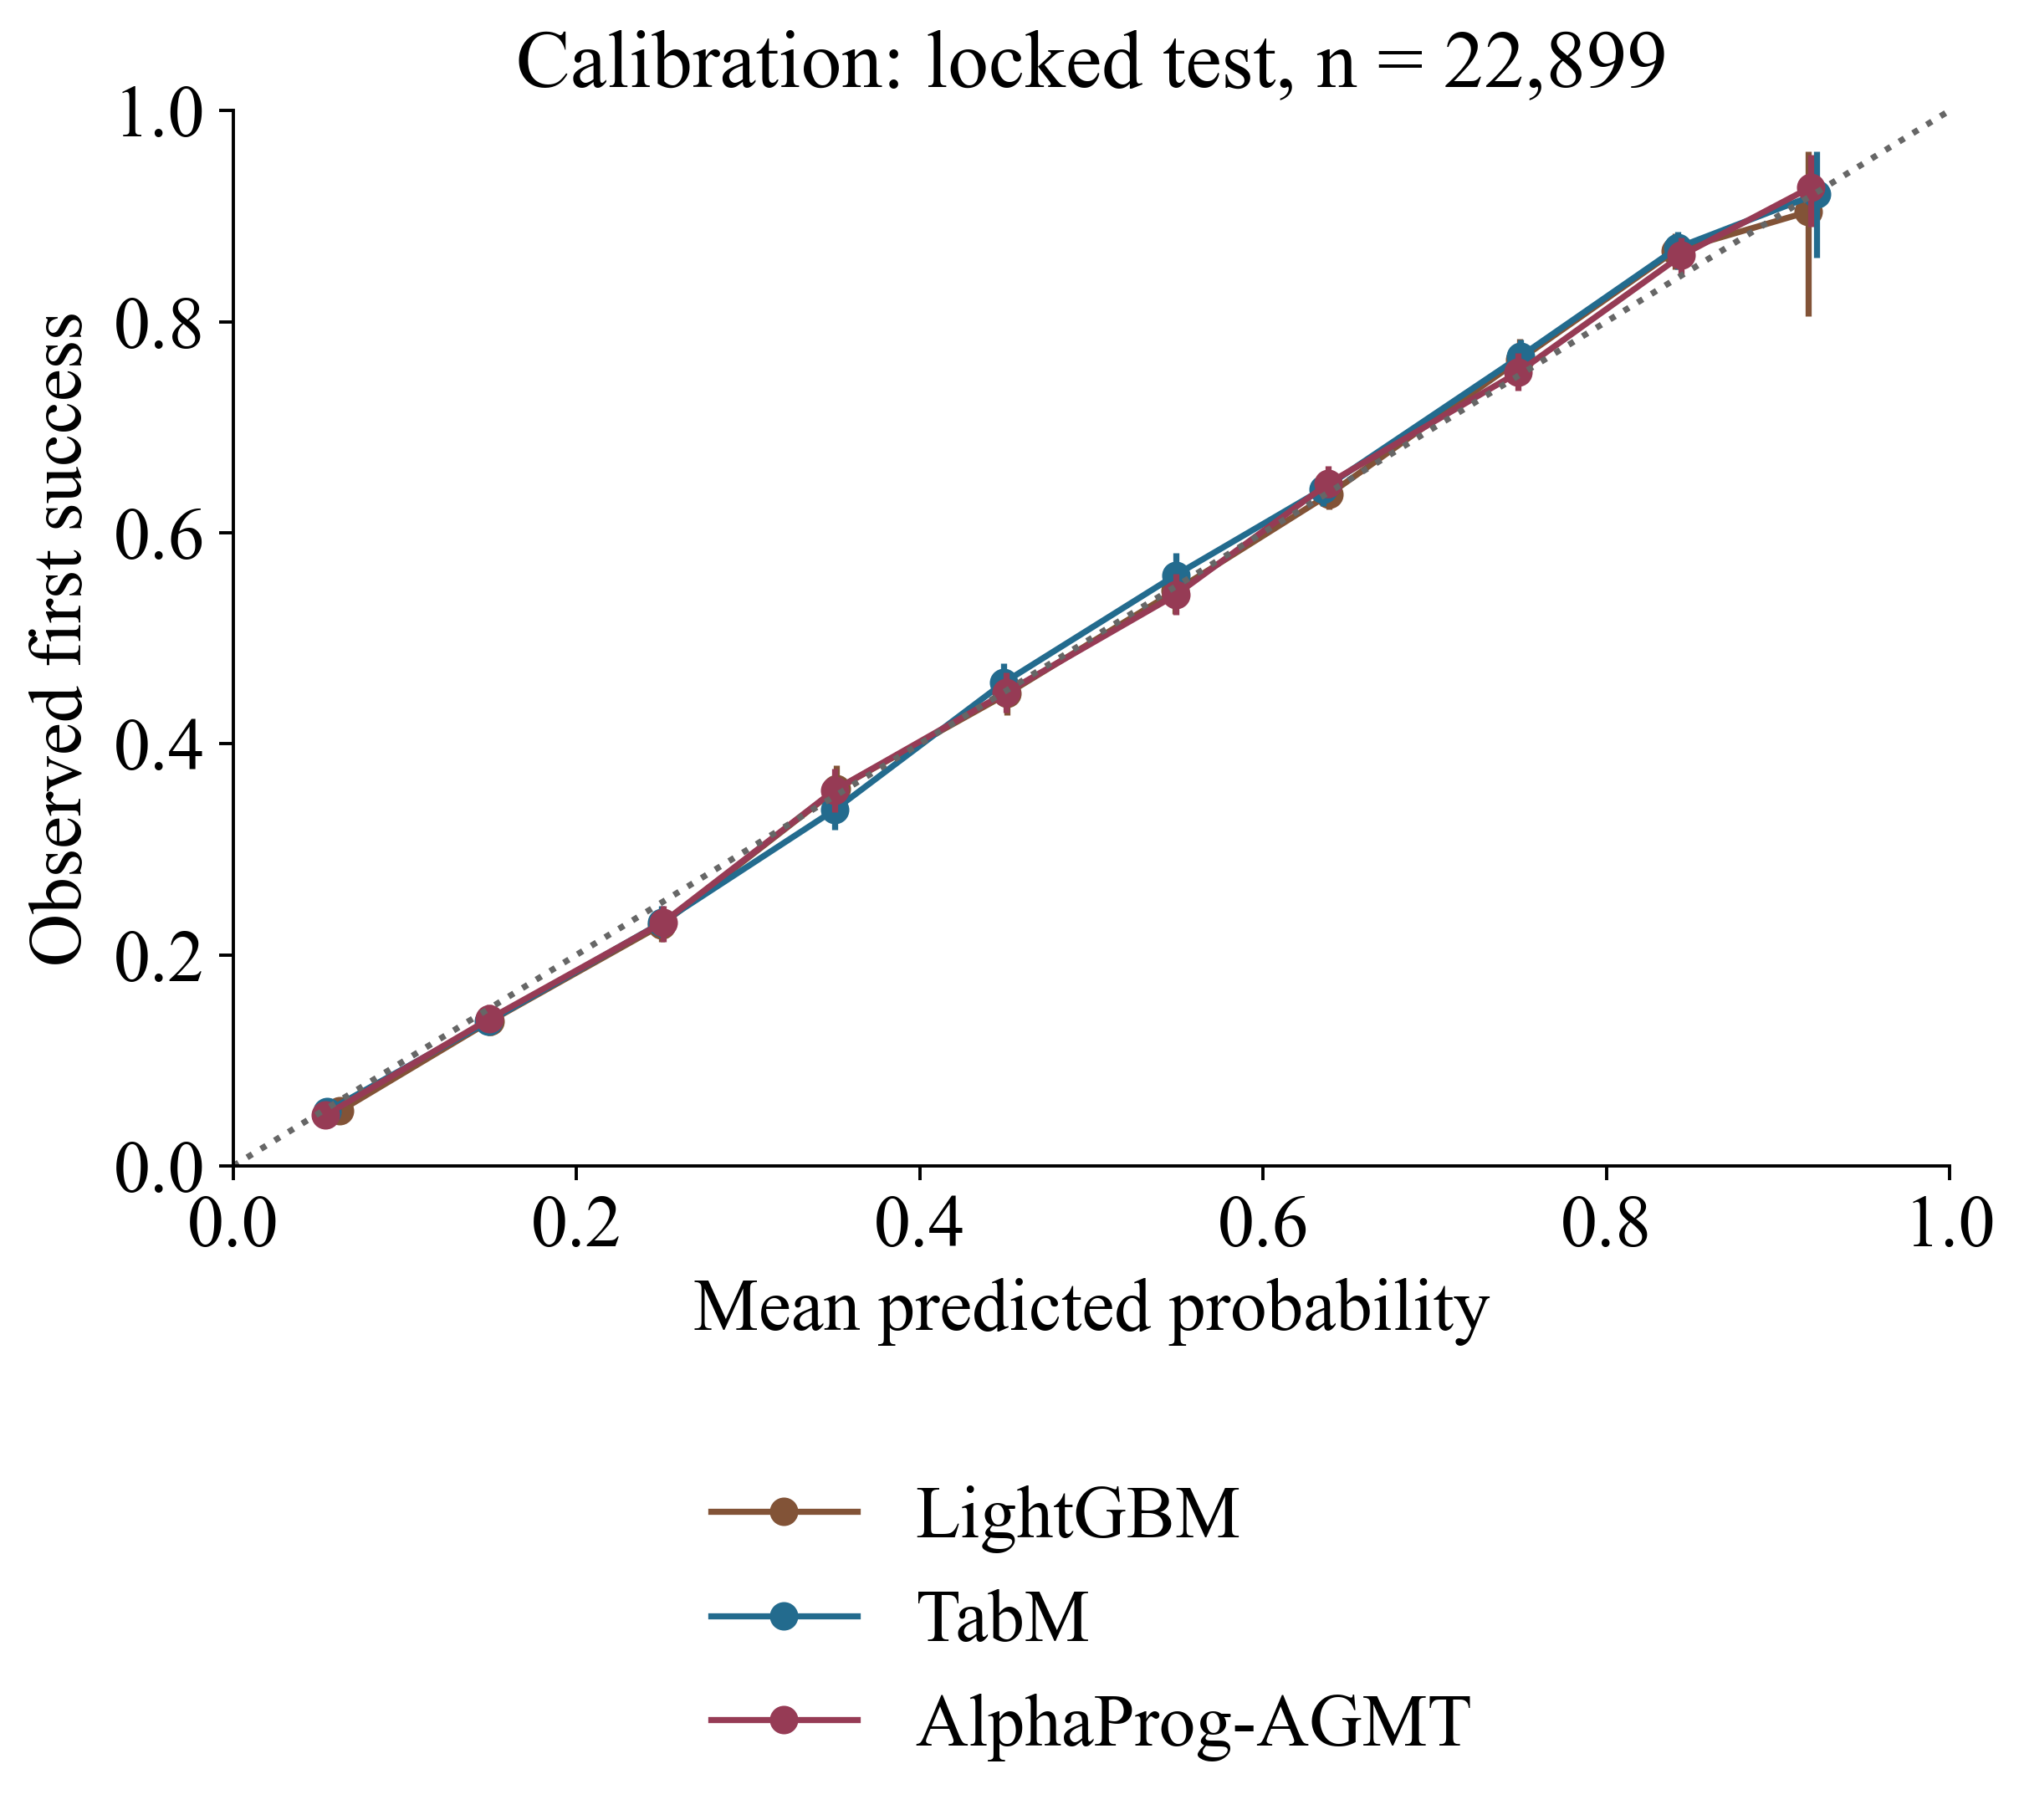

In [15]:
diagnostic_models = list(dict.fromkeys([BEST_ML, BEST_DL, "AlphaProg-AGMT"]))
fig, ax = plt.subplots(figsize=(6.8, 6.1), layout="constrained")
calibration_sources = []
for name, color in zip(diagnostic_models, ["#825337", "#236B8E", "#963B55"]):
    bins = calibration_bins(test_data, probability_matrix[name].to_numpy())
    bins["Model"] = name
    calibration_sources.append(bins)
    if bins.empty:
        continue
    ax.plot(bins.Predicted, bins.Observed, marker="o", color=color, label=name)
    ax.vlines(
        bins.Predicted, bins.CI_low, bins.CI_high, color=color, linewidth=1.5
    )
ax.plot([0, 1], [0, 1], linestyle=":", color="#666666")
ax.set(
    xlabel="Mean predicted probability",
    ylabel="Observed first success",
    xlim=(0, 1),
    ylim=(0, 1),
    title=f"Calibration: locked test, n = {len(test_data):,}",
)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.24), frameon=False)
pd.concat(calibration_sources).to_csv(
    ROOT / "artifacts/06_calibration_bins.csv", index=False
)
save_figure(fig, "06_calibration")
plt.show()


## Подгруппы доступности истории и сложности задания

Режимы определены до просмотра тестовых метрик: нет истории, 1–8, 9–32 и более 32 прошлых попыток; разделы 1–3, 4–6 и 7–9. Показываются все строки групп, без отбора только благоприятных результатов. Величины не изолируют причинное влияние опыта или сложности.

In [16]:
subgroup_definitions = {
    "History": pd.cut(
        test_data.history_n,
        [-1, 0, 8, 32, np.inf],
        labels=["0", "1–8", "9–32", "33+"],
    ),
    "Task section": pd.cut(
        test_data.q_level, [0, 3, 6, 9], labels=["1–3", "4–6", "7–9"]
    ),
}
subgroup_rows = []
for dimension, groups in subgroup_definitions.items():
    for group in groups.cat.categories:
        retained = groups.eq(group).to_numpy()
        if not retained.any():
            continue
        for name in diagnostic_models:
            losses = binary_loss(
                test_data.loc[retained, "y"].to_numpy(),
                probability_matrix.loc[retained, name].to_numpy(),
            )
            estimate, lower, upper = learner_mean_interval(
                losses, test_data.loc[retained, "student"].to_numpy(), 500
            )
            subgroup_rows.append(
                {
                    "Model": name,
                    "Split": "Locked test",
                    "Dimension": dimension,
                    "Group": str(group),
                    "n": int(retained.sum()),
                    "LogLoss": estimate,
                    "CI_low": lower,
                    "CI_high": upper,
                }
            )
subgroup_results = pd.DataFrame(subgroup_rows)
subgroup_results.to_csv(ROOT / "artifacts/06_all_subgroups.csv", index=False)
table(
    subgroup_results[subgroup_results.Dimension.eq("History")].drop(
        columns="Dimension"
    ),
    "Ошибка по доступной истории; LogLoss ↓",
    "06_history_subgroups",
)


Ошибка по доступной истории; LogLoss ↓

,Model,Split,Group,n,LogLoss,CI_low,CI_high
0,LightGBM,Locked test,0,1754,0.65566,0.64322,0.66965
1,TabM,Locked test,0,1754,0.65491,0.64313,0.66842
2,AlphaProg-AGMT,Locked test,0,1754,0.65560,0.64305,0.66961
3,LightGBM,Locked test,1–8,10488,0.56529,0.55684,0.57409
4,TabM,Locked test,1–8,10488,0.56674,0.55780,0.57581
5,AlphaProg-AGMT,Locked test,1–8,10488,0.55957,0.55036,0.56880
6,LightGBM,Locked test,9–32,9608,0.49411,0.48342,0.50682
7,TabM,Locked test,9–32,9608,0.49512,0.48392,0.50837
8,AlphaProg-AGMT,Locked test,9–32,9608,0.48610,0.47508,0.49867
9,LightGBM,Locked test,33+,1049,0.41905,0.38296,0.45690


In [17]:
table(
    subgroup_results[subgroup_results.Dimension.eq("Task section")].drop(
        columns="Dimension"
    ),
    "Ошибка по разделам заданий; LogLoss ↓",
    "06_task_subgroups",
)


Ошибка по разделам заданий; LogLoss ↓

,Model,Split,Group,n,LogLoss,CI_low,CI_high
0,LightGBM,Locked test,1–3,18422,0.54559,0.53817,0.55224
1,TabM,Locked test,1–3,18422,0.54748,0.54057,0.55452
2,AlphaProg-AGMT,Locked test,1–3,18422,0.53996,0.53255,0.54670
3,LightGBM,Locked test,4–6,4027,0.51298,0.49433,0.53232
4,TabM,Locked test,4–6,4027,0.50788,0.48911,0.52618
5,AlphaProg-AGMT,Locked test,4–6,4027,0.50137,0.48235,0.52106
6,LightGBM,Locked test,7–9,450,0.33134,0.22437,0.42551
7,TabM,Locked test,7–9,450,0.33339,0.21559,0.44260
8,AlphaProg-AGMT,Locked test,7–9,450,0.33485,0.21631,0.44235


## Цензурированная трудоёмкость

Совместная NLL использует весь наблюдённый процесс до первого успеха или цензурирования. Дополнительные Brier-оценки на горизонтах 1, 3, 5 и 10 запусков корректируются на цензурирование с помощью обратной Kaplan–Meier кривой, оценённой на train. IPCW здесь предполагает независимость цензурирования; это диагностическое допущение, которое архив сам по себе не подтверждает. Число запусков не интерпретируется как время освоения навыка.

Для оценки цензурирования применяется обратная оценка Kaplan–Meier, обученная только на train. При совпадении числа запусков наблюдённый успех происходит раньше цензурирования после этого запуска и исключается из знаменателя соответствующего скачка; такой порядок согласуется с [описанием reverse Kaplan–Meier](https://scikit-survival.readthedocs.io/en/stable/api/generated/sksurv.nonparametric.kaplan_meier_estimator.html). Запись, цензурированная после запуска $r$, информативна до горизонта $r$ включительно. Используются веса $1/\hat G(r)$ с $\hat G(r)=P(C\ge r)$. [IPCW Brier](https://scikit-survival.readthedocs.io/en/stable/api/generated/sksurv.metrics.brier_score.html) требует независимого цензурирования; для этого образовательного архива данное предположение не подтверждено. Поэтому результат приводится как условная диагностика, а не доказательство ненаблюдаемого успеха.

Горизонт первого запуска совпадает с Brier бинарной цели, уже представленным выше. Это равенство проверяется молча; его повторная таблица не строится. Здесь приведены совместная NLL и горизонты 3, 5 и 10 запусков.

In [19]:
# ---------------------------------------------------------------------
# Censored effort quality:
# joint NLL + IPCW Brier at prespecified run horizons
# ---------------------------------------------------------------------

FLOAT32_TOL = 10 * np.finfo(np.float32).eps

effort_horizons = [int(horizon) for horizon in frozen["effort_horizons"]]

assert 1 in effort_horizons, (
    "The frozen effort protocol must include horizon 1 "
    "for the first-run consistency check."
)

assert train_data.effort_runs.ge(1).all(), (
    "Every training observation in the first-run prediction cohort "
    "must contain at least one registered execution."
)

assert test_data.effort_runs.ge(1).all(), (
    "Every locked-test observation in the first-run prediction cohort "
    "must contain at least one registered execution."
)


# ---------------------------------------------------------------------
# 1. Mean hazard for models without their own joint effort head
# ---------------------------------------------------------------------

hazard_stack = np.stack(
    [
        np.asarray(
            hazard_by_seed[seed],
            dtype=np.float64,
        )
        for seed in SEEDS
    ],
    axis=0,
)

assert hazard_stack.ndim == 2
assert hazard_stack.shape[1] == len(test_data)
assert np.isfinite(hazard_stack).all()

mean_hazard = hazard_stack.mean(axis=0)

assert mean_hazard.shape == (len(test_data),)
assert np.isfinite(mean_hazard).all()
assert np.logical_and(
    mean_hazard > 0,
    mean_hazard < 1,
).all()


# ---------------------------------------------------------------------
# 2. Build canonical joint forecasts
#
# Column 0 = probability of first-run success.
# Column 1 = conditional tail hazard after a failed first run.
#
# The already constructed probability_matrix is treated as the
# canonical source of first-run probabilities. This avoids obtaining
# the same ensemble probability through two slightly different
# floating-point aggregation paths.
# ---------------------------------------------------------------------

joint_forecasts: dict[str, np.ndarray] = {}

for name in PRIMARY_MODELS[:10]:
    success_probability = probability_matrix[name].to_numpy(dtype=np.float64)

    assert success_probability.shape == (len(test_data),)
    assert np.isfinite(success_probability).all()
    assert np.logical_and(
        success_probability >= EPSILON,
        success_probability <= 1 - EPSILON,
    ).all()

    joint_forecasts[name] = np.column_stack(
        [
            success_probability,
            mean_hazard,
        ]
    )


# GraphTrajectory and AlphaProg-AGMT have their own joint predictions.
# Their first column must agree with the canonical probability ensemble.
# The second column is averaged directly across seeds.
for name in [
    "GraphTrajectory",
    "AlphaProg-AGMT",
]:
    joint_stack = np.stack(
        [
            np.asarray(
                joint_by_seed[(name, seed)],
                dtype=np.float64,
            )
            for seed in SEEDS
        ],
        axis=0,
    )

    assert joint_stack.ndim == 3
    assert joint_stack.shape == (
        len(SEEDS),
        len(test_data),
        2,
    )
    assert np.isfinite(joint_stack).all()

    mean_joint = joint_stack.mean(axis=0)

    canonical_success = probability_matrix[name].to_numpy(dtype=np.float64)

    # These represent the same seed-averaged first-run forecast.
    # A float32-scale tolerance is appropriate because neural-network
    # predictions were originally produced from float32 tensors.
    assert np.allclose(
        mean_joint[:, 0],
        canonical_success,
        atol=FLOAT32_TOL,
        rtol=FLOAT32_TOL,
    ), (
        f"Inconsistent first-run ensemble probability for {name}. "
        "The joint and primary prediction paths should represent "
        "the same frozen seed ensemble."
    )

    joint_forecasts[name] = np.column_stack(
        [
            canonical_success,
            mean_joint[:, 1],
        ]
    )


assert set(diagnostic_models).issubset(joint_forecasts)


# ---------------------------------------------------------------------
# 3. Estimate censoring distribution from TRAIN only
# ---------------------------------------------------------------------

censor_times, censor_probability = censoring_survival(train_data)

assert len(censor_times) == len(censor_probability)
assert len(censor_times) > 0
assert np.isfinite(censor_probability).all()
assert np.logical_and(
    censor_probability > 0,
    censor_probability <= 1,
).all()


# ---------------------------------------------------------------------
# 4. Effort metrics on the locked test
# ---------------------------------------------------------------------

test_target = test_data.y.to_numpy(dtype=np.int8)

effort_rows = []

for name in diagnostic_models:
    forecast = joint_forecasts[name]

    assert forecast.shape == (
        len(test_data),
        2,
    )
    assert np.isfinite(forecast).all()

    row = {
        "Model": name,
        "Split": "Locked test",
        "n": len(test_data),
        "Effort_NLL": censored_effort_nll(
            test_data.y.to_numpy(),
            test_data.effort_observed.to_numpy(),
            test_data.effort_runs.to_numpy(),
            forecast[:, 0],
            forecast[:, 1],
        ),
    }

    for horizon in effort_horizons:
        ipcw = horizon_ipcw(
            test_data,
            forecast,
            horizon,
            censor_times,
            censor_probability,
        )

        assert len(ipcw) == len(test_data)
        assert np.isfinite(ipcw["Brier_contribution"]).all()

        # At horizon 1, the survival target must be exactly the
        # first-run classification target y.
        #
        # Because every member of the prediction cohort has at least
        # one observed execution, there is no censoring before the
        # first-run outcome. Therefore IPCW weights must also be 1.
        if horizon == 1:
            horizon_one_target = ipcw["Success"].to_numpy(dtype=np.int8)

            horizon_one_weight = ipcw["Weight"].to_numpy(dtype=np.float64)

            assert np.array_equal(
                horizon_one_target,
                test_target,
            ), (
                f"Horizon-1 effort target is inconsistent "
                f"with first-run y for {name}."
            )

            assert np.allclose(
                horizon_one_weight,
                1.0,
                atol=1e-12,
                rtol=0.0,
            ), (
                "IPCW weights at run 1 must equal 1 because "
                "all observations in the prediction cohort "
                "contain an observed first execution."
            )

        row[f"Brier_run_{horizon}"] = float(ipcw["Brier_contribution"].mean())

    effort_rows.append(row)


effort_results = pd.DataFrame(effort_rows)


# ---------------------------------------------------------------------
# 5. Scientific consistency check for horizon 1
#
# We verify the identity in three stages:
#
#   (a) same binary target,
#   (b) same canonical probability,
#   (c) same Brier score up to floating-point precision.
#
# We intentionally do NOT require bitwise equality between calculations
# performed through NumPy, pandas and scikit-learn.
# ---------------------------------------------------------------------

calibration_brier = calibration_results.set_index("Model")["Brier"]

for row in effort_results.itertuples(index=False):
    first_run_probability = joint_forecasts[row.Model][:, 0]

    direct_first_run_brier = brier_score_loss(
        test_target,
        first_run_probability,
    )

    # horizon_ipcw() at h=1 should reduce to the ordinary Brier score.
    assert np.isclose(
        row.Brier_run_1,
        direct_first_run_brier,
        atol=1e-12,
        rtol=1e-10,
    ), (
        f"Horizon-1 IPCW Brier mismatch for {row.Model}: "
        f"{row.Brier_run_1:.12g} vs "
        f"{direct_first_run_brier:.12g}."
    )

    reported_first_run_brier = float(calibration_brier.loc[row.Model])

    # calibration_results uses the common probability diagnostic path;
    # allow only float32-scale numerical differences, not a substantive
    # metric discrepancy.
    assert np.isclose(
        direct_first_run_brier,
        reported_first_run_brier,
        atol=FLOAT32_TOL,
        rtol=FLOAT32_TOL,
    ), (
        f"Primary and effort Brier calculations disagree "
        f"for {row.Model}: "
        f"{direct_first_run_brier:.12g} vs "
        f"{reported_first_run_brier:.12g}."
    )


# Save only after all scientific consistency checks have passed.
effort_results.to_csv(
    ROOT / "artifacts" / "06_all_effort_quality.csv",
    index=False,
)


# Horizon 1 is intentionally omitted from the visible table because it
# duplicates the ordinary first-run Brier score already reported above.
visible_effort_results = effort_results.drop(columns="Brier_run_1")

table(
    visible_effort_results,
    "Совместная NLL и IPCW Brier на запусках 3, 5, 10 ↓",
    "06_effort_quality",
)


Совместная NLL и IPCW Brier на запусках 3, 5, 10 ↓

,Model,Split,n,Effort_NLL,Brier_run_3,Brier_run_5,Brier_run_10
0,LightGBM,Locked test,22899,1.57781,0.14379,0.10917,0.05974
1,TabM,Locked test,22899,1.57847,0.14368,0.10904,0.05974
2,AlphaProg-AGMT,Locked test,22899,1.56754,0.14163,0.10761,0.05913


## Неопределённость эффекта для вторичной цели

Положительный эффект означает меньшую среднюю NLL наблюдённой записи у AlphaProg-AGMT. Сравниваются два сильных ориентира, выбранных до теста, с тем же hazard-контролем. Bootstrap целых учащихся даёт отдельные 95% интервалы; они не являются одновременными интервалами для всей совокупности метрик и не заменяют основной анализ LogLoss.

In [20]:
effort_effect_rows = []
candidate_joint = joint_forecasts["AlphaProg-AGMT"]
candidate_effort_loss = censored_effort_loss(
    test_data.y.to_numpy(),
    test_data.effort_observed.to_numpy(),
    test_data.effort_runs.to_numpy(),
    candidate_joint[:, 0],
    candidate_joint[:, 1],
)
for comparator in frozen["secondary_effort_comparators"]:
    comparator_joint = joint_forecasts[comparator]
    comparator_loss = censored_effort_loss(
        test_data.y.to_numpy(),
        test_data.effort_observed.to_numpy(),
        test_data.effort_runs.to_numpy(),
        comparator_joint[:, 0],
        comparator_joint[:, 1],
    )
    effect, lower, upper = learner_mean_interval(
        comparator_loss - candidate_effort_loss,
        test_data.student.to_numpy(),
        frozen["primary_bootstrap_repetitions"],
    )
    effort_effect_rows.append(
        {
            "Model": "AlphaProg-AGMT",
            "Comparator": comparator,
            "Split": "Locked test",
            "n": len(test_data),
            "Effect_NLL": effect,
            "CI_low": lower,
            "CI_high": upper,
        }
    )
effort_effect_results = pd.DataFrame(effort_effect_rows)
table(
    effort_effect_results,
    "Вторичная цель: NLL comparator − NLL AlphaProg-AGMT; 95% CI",
    "06_effort_effects",
)


Вторичная цель: NLL comparator − NLL AlphaProg-AGMT; 95% CI

,Model,Comparator,Split,n,Effect_NLL,CI_low,CI_high
0,AlphaProg-AGMT,LightGBM,Locked test,22899,0.01027,0.00858,0.01213
1,AlphaProg-AGMT,TabM,Locked test,22899,0.01093,0.00903,0.01284


## Согласование прогноза с горизонтом числа запусков

Полотно сопоставляет среднюю предсказанную вероятность успеха до заданного запуска с наблюдаемой IPCW-оценкой. Оно показывает форму распределения дополнительной цели, а не повторяет таблицу ошибок. Для наблюдаемой кривой построены точечные 95% интервалы по 300 повторным выборкам целых учащихся; оценка цензурирования, обученная на train, при этом фиксирована. Зависимость результатов от модели цензурирования и постоянного условного hazard сохраняется. Выход оценки или её интервала за единицу при конечной выборке не обрезается и указывает на ограничения взвешенной оценки.

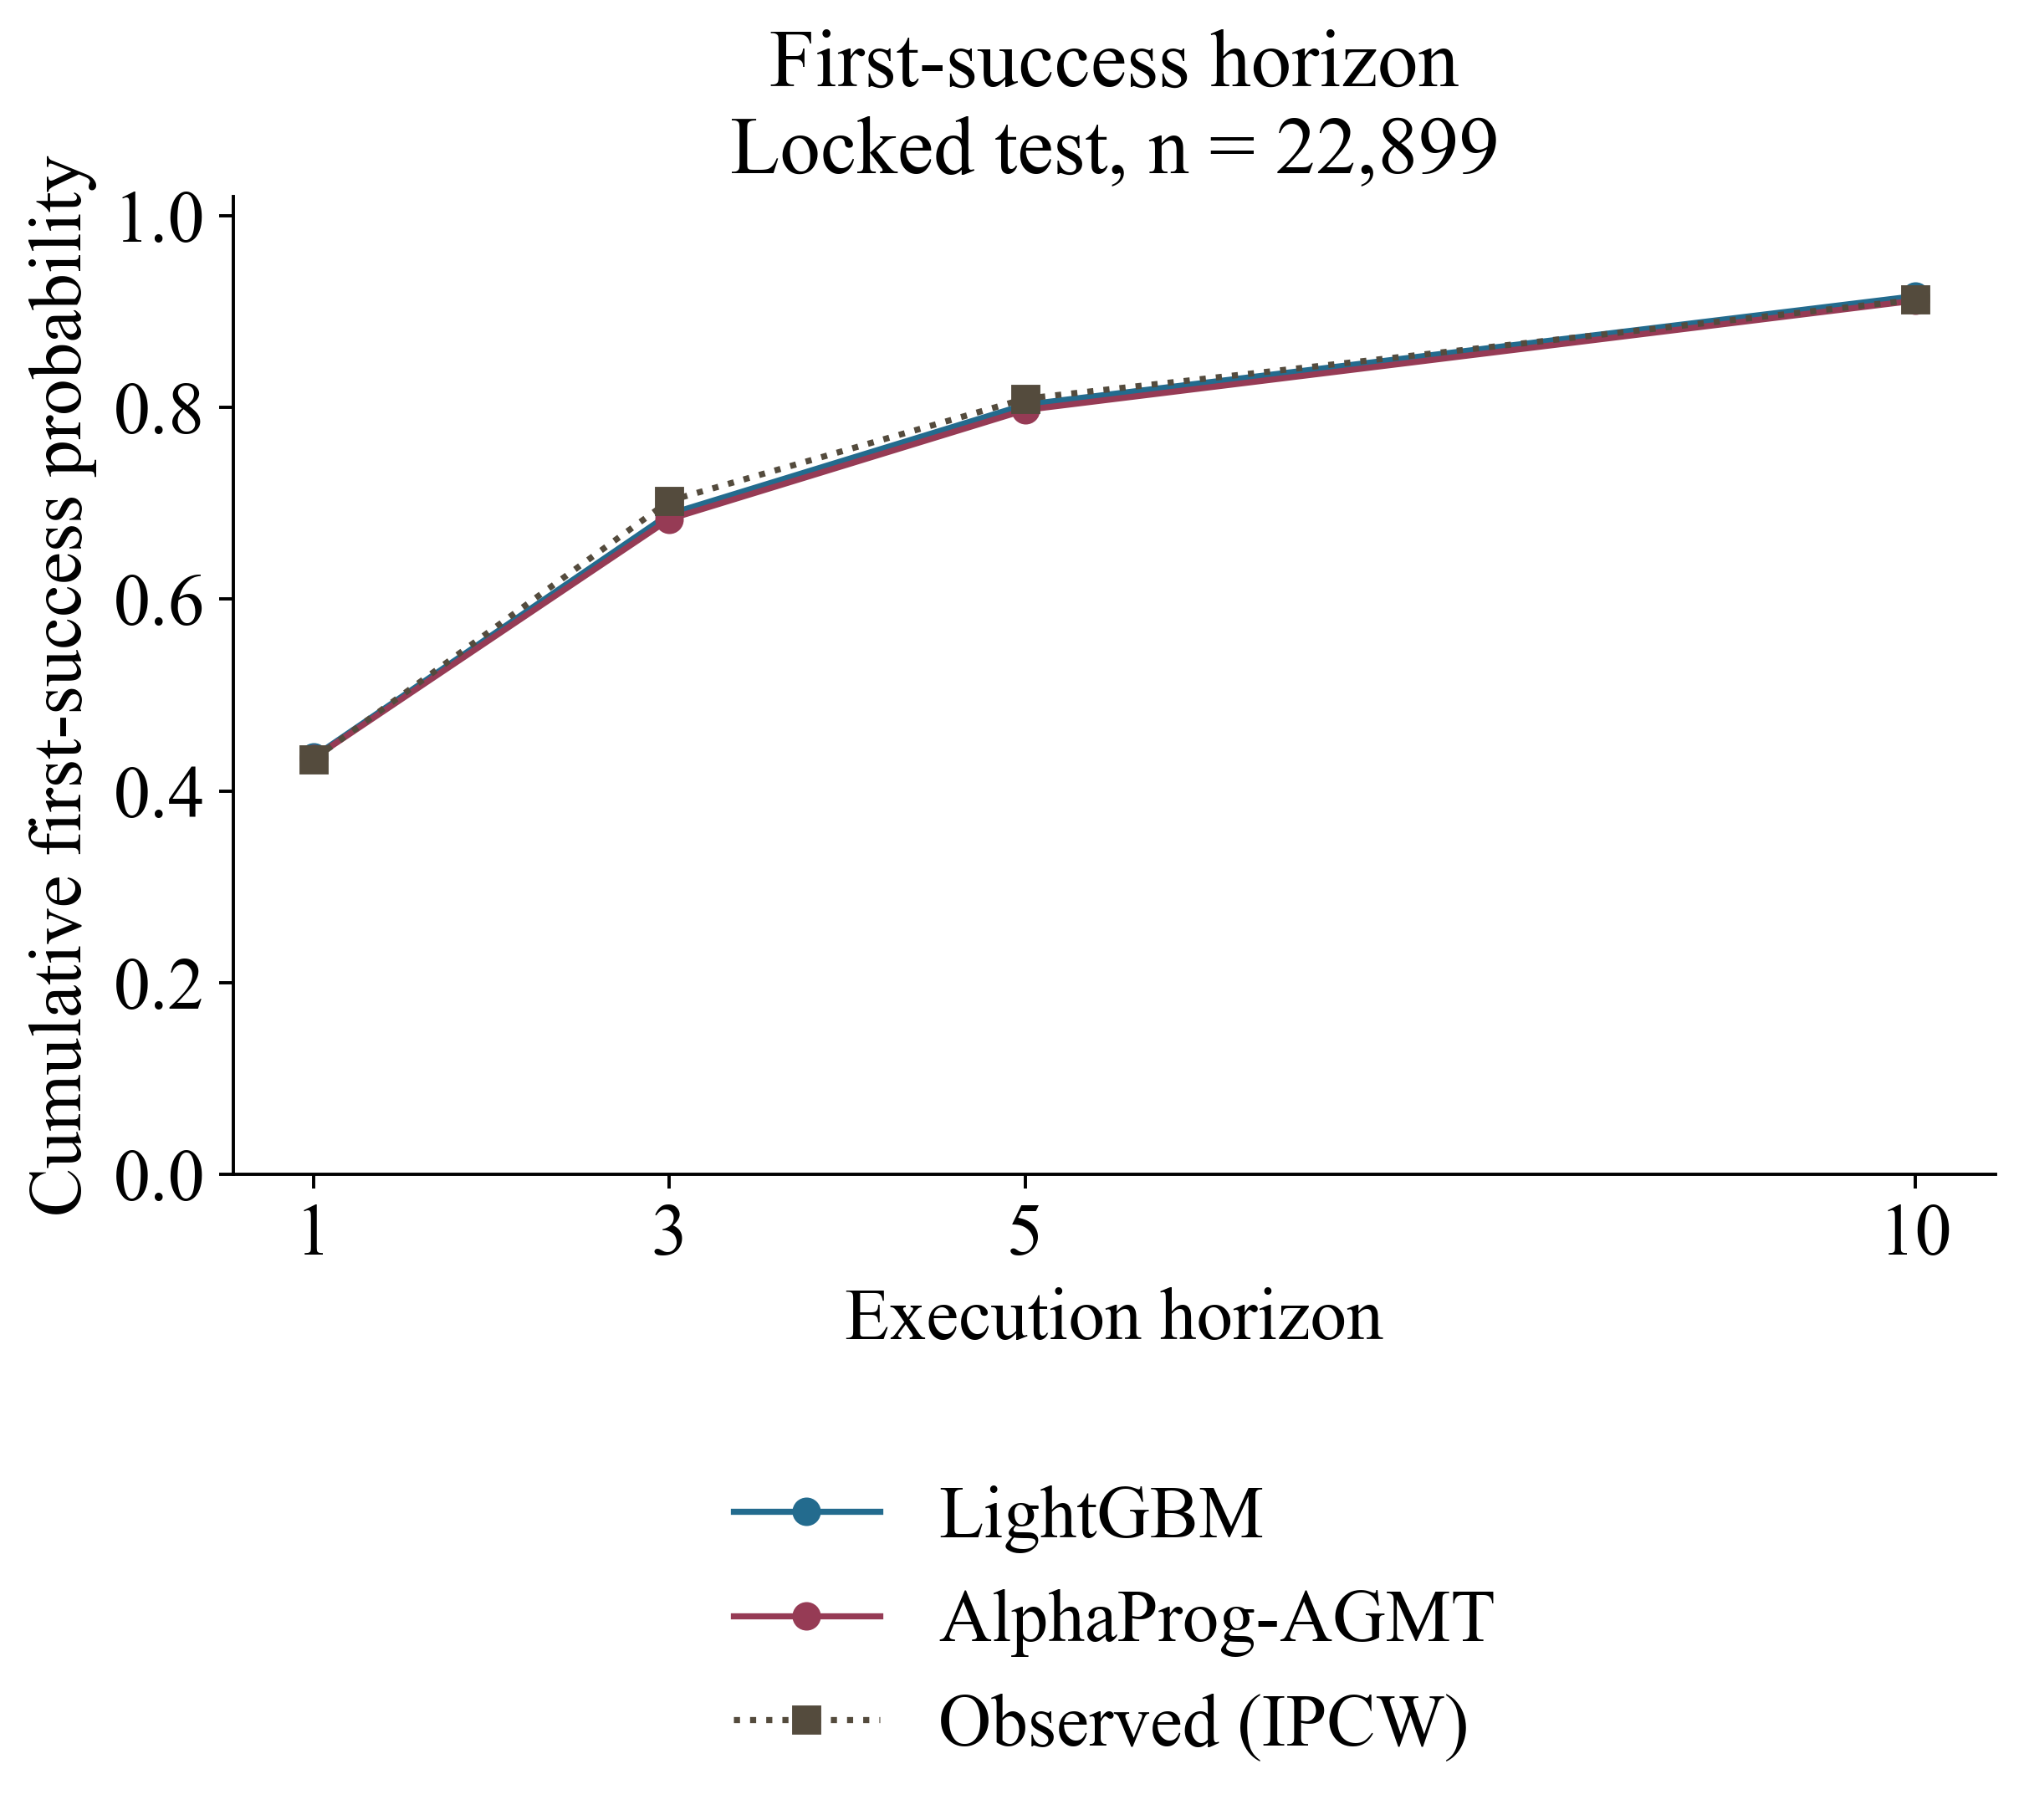

In [21]:
effort_plot_models = list(dict.fromkeys([BASE_NAME, "AlphaProg-AGMT"]))
effort_curve_rows, observed_curve_rows = [], []
for horizon in frozen["effort_horizons"]:
    for name in effort_plot_models:
        contributions = horizon_ipcw(
            test_data,
            joint_forecasts[name],
            horizon,
            censor_times,
            censor_probability,
        )
        effort_curve_rows.append(
            {
                "Model": name,
                "Split": "Locked test",
                "n": len(test_data),
                "Horizon": horizon,
                "Cumulative_probability": contributions.Probability.mean(),
            }
        )
    observed, lower, upper = learner_mean_interval(
        (contributions.Weight * contributions.Success).to_numpy(),
        test_data.student.to_numpy(),
        repetitions=300,
    )
    observed_curve_rows.append(
        {
            "Horizon": horizon,
            "Observed_IPCW": observed,
            "CI_low": lower,
            "CI_high": upper,
        }
    )
effort_curve = pd.DataFrame(effort_curve_rows)
observed_effort_curve = pd.DataFrame(observed_curve_rows)
fig, ax = plt.subplots(figsize=(6.8, 6.1), layout="constrained")
for name, color in zip(effort_plot_models, ["#236B8E", "#963B55"]):
    rows = effort_curve.loc[effort_curve.Model.eq(name)]
    ax.plot(
        rows.Horizon,
        rows.Cumulative_probability,
        marker="o",
        color=color,
        label=name,
    )
ax.plot(
    observed_effort_curve.Horizon,
    observed_effort_curve.Observed_IPCW,
    marker="s",
    linestyle=":",
    color="#544B3D",
    label="Observed (IPCW)",
)
ax.vlines(
    observed_effort_curve.Horizon,
    observed_effort_curve.CI_low,
    observed_effort_curve.CI_high,
    color="#544B3D",
    linewidth=1.5,
)
ax.set_xticks(frozen["effort_horizons"])
ax.set(
    xlabel="Execution horizon",
    ylabel="Cumulative first-success probability",
    title=f"First-success horizon\nLocked test, n = {len(test_data):,}",
    ylim=(0, max(1.02, float(observed_effort_curve.CI_high.max()) + 0.02)),
)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), frameon=False)
effort_curve.to_csv(
    ROOT / "artifacts/06_effort_forecast_curve.csv", index=False
)
observed_effort_curve.to_csv(
    ROOT / "artifacts/06_effort_observed_curve.csv", index=False
)
save_figure(fig, "06_effort_horizons")
plt.show()


## Устойчивость к отсутствующей истории

Для 10% и 30% учащихся детерминированно маскируется вся история. Описание текущего задания сохраняется, а входы переводятся в тот же режим отсутствия контекста, который встречается в обучении. Это сценарий недоступного журнала, а не новый образовательный эксперимент. Модели не переобучаются; все три seeds используются с прежними весами.

In [22]:
def mask_history(
    frame: pd.DataFrame,
    history: dict[str, np.ndarray],
    sequences: dict[str, np.ndarray],
    fraction: float,
) -> tuple[pd.DataFrame, dict, dict, np.ndarray]:
    """Simulate unavailable learner histories while preserving task descriptions."""
    assert 0 <= fraction <= 1
    learner_mask = frame.student.map(
        lambda student: int(
            hashlib.sha256(
                f"{SEED}:history-mask:{student}".encode()
            ).hexdigest()[:12],
            16,
        )
        / 16**12
        < fraction
    ).to_numpy()
    altered_frame = frame.copy()
    altered_history = {name: values.copy() for name, values in history.items()}
    altered_sequence = {
        name: values.copy() for name, values in sequences.items()
    }
    for name in numeric_names:
        if name.startswith("hist_"):
            altered_frame.loc[learner_mask, name] = np.nan
        elif name.startswith("history_"):
            altered_frame.loc[learner_mask, name] = 0
        elif name.startswith("skill_"):
            altered_frame.loc[learner_mask, name] = (
                0.5 if name.endswith("_rate") else 0
            )
    altered_history["length"][learner_mask] = 0
    altered_history["graph_id"][learner_mask] = 0
    altered_history["process"][learner_mask] = np.nan
    for name in altered_sequence:
        altered_sequence[name][learner_mask] = 0
    altered_sequence["task"][learner_mask, 0] = (
        frame.loc[learner_mask, "problem"].map(problem_to_index).to_numpy()
    )
    altered_sequence["concept"][learner_mask, 0] = (
        frame.loc[learner_mask, "problem"].map(concept_by_problem).to_numpy()
    )
    assert np.array_equal(
        altered_frame[contract["categorical"]].to_numpy(),
        frame[contract["categorical"]].to_numpy(),
    )
    return altered_frame, altered_history, altered_sequence, learner_mask


def robustness_forecast(
    frame: pd.DataFrame,
    history: dict[str, np.ndarray],
    sequence: dict[str, np.ndarray],
) -> dict[str, np.ndarray]:
    """Evaluate fixed experts and fusion; neither training nor retuning occurs."""
    result = {
        name: [] for name in list(dict.fromkeys([BASE_NAME, "AlphaProg-AGMT"]))
    }
    for seed in SEEDS:
        base_probability = (
            predict_modern(BASE_NAME, seed, frame, sequence)
            if BASE_NAME in MODERN_MODELS
            else predict_tabular(BASE_NAME, seed, frame)
        )
        base_joint = np.c_[base_probability, predict_hazard(seed, frame)]
        graph_joint = predict_graph("FullGraph", seed, frame, history)
        forecast, _, _ = apply_fitted_gate(
            frame,
            base_joint,
            graph_joint,
            experiments["gates"][("AlphaProg-AGMT", seed)],
        )
        result[BASE_NAME].append(base_probability)
        result["AlphaProg-AGMT"].append(forecast[:, 0])
    return {name: np.mean(values, axis=0) for name, values in result.items()}


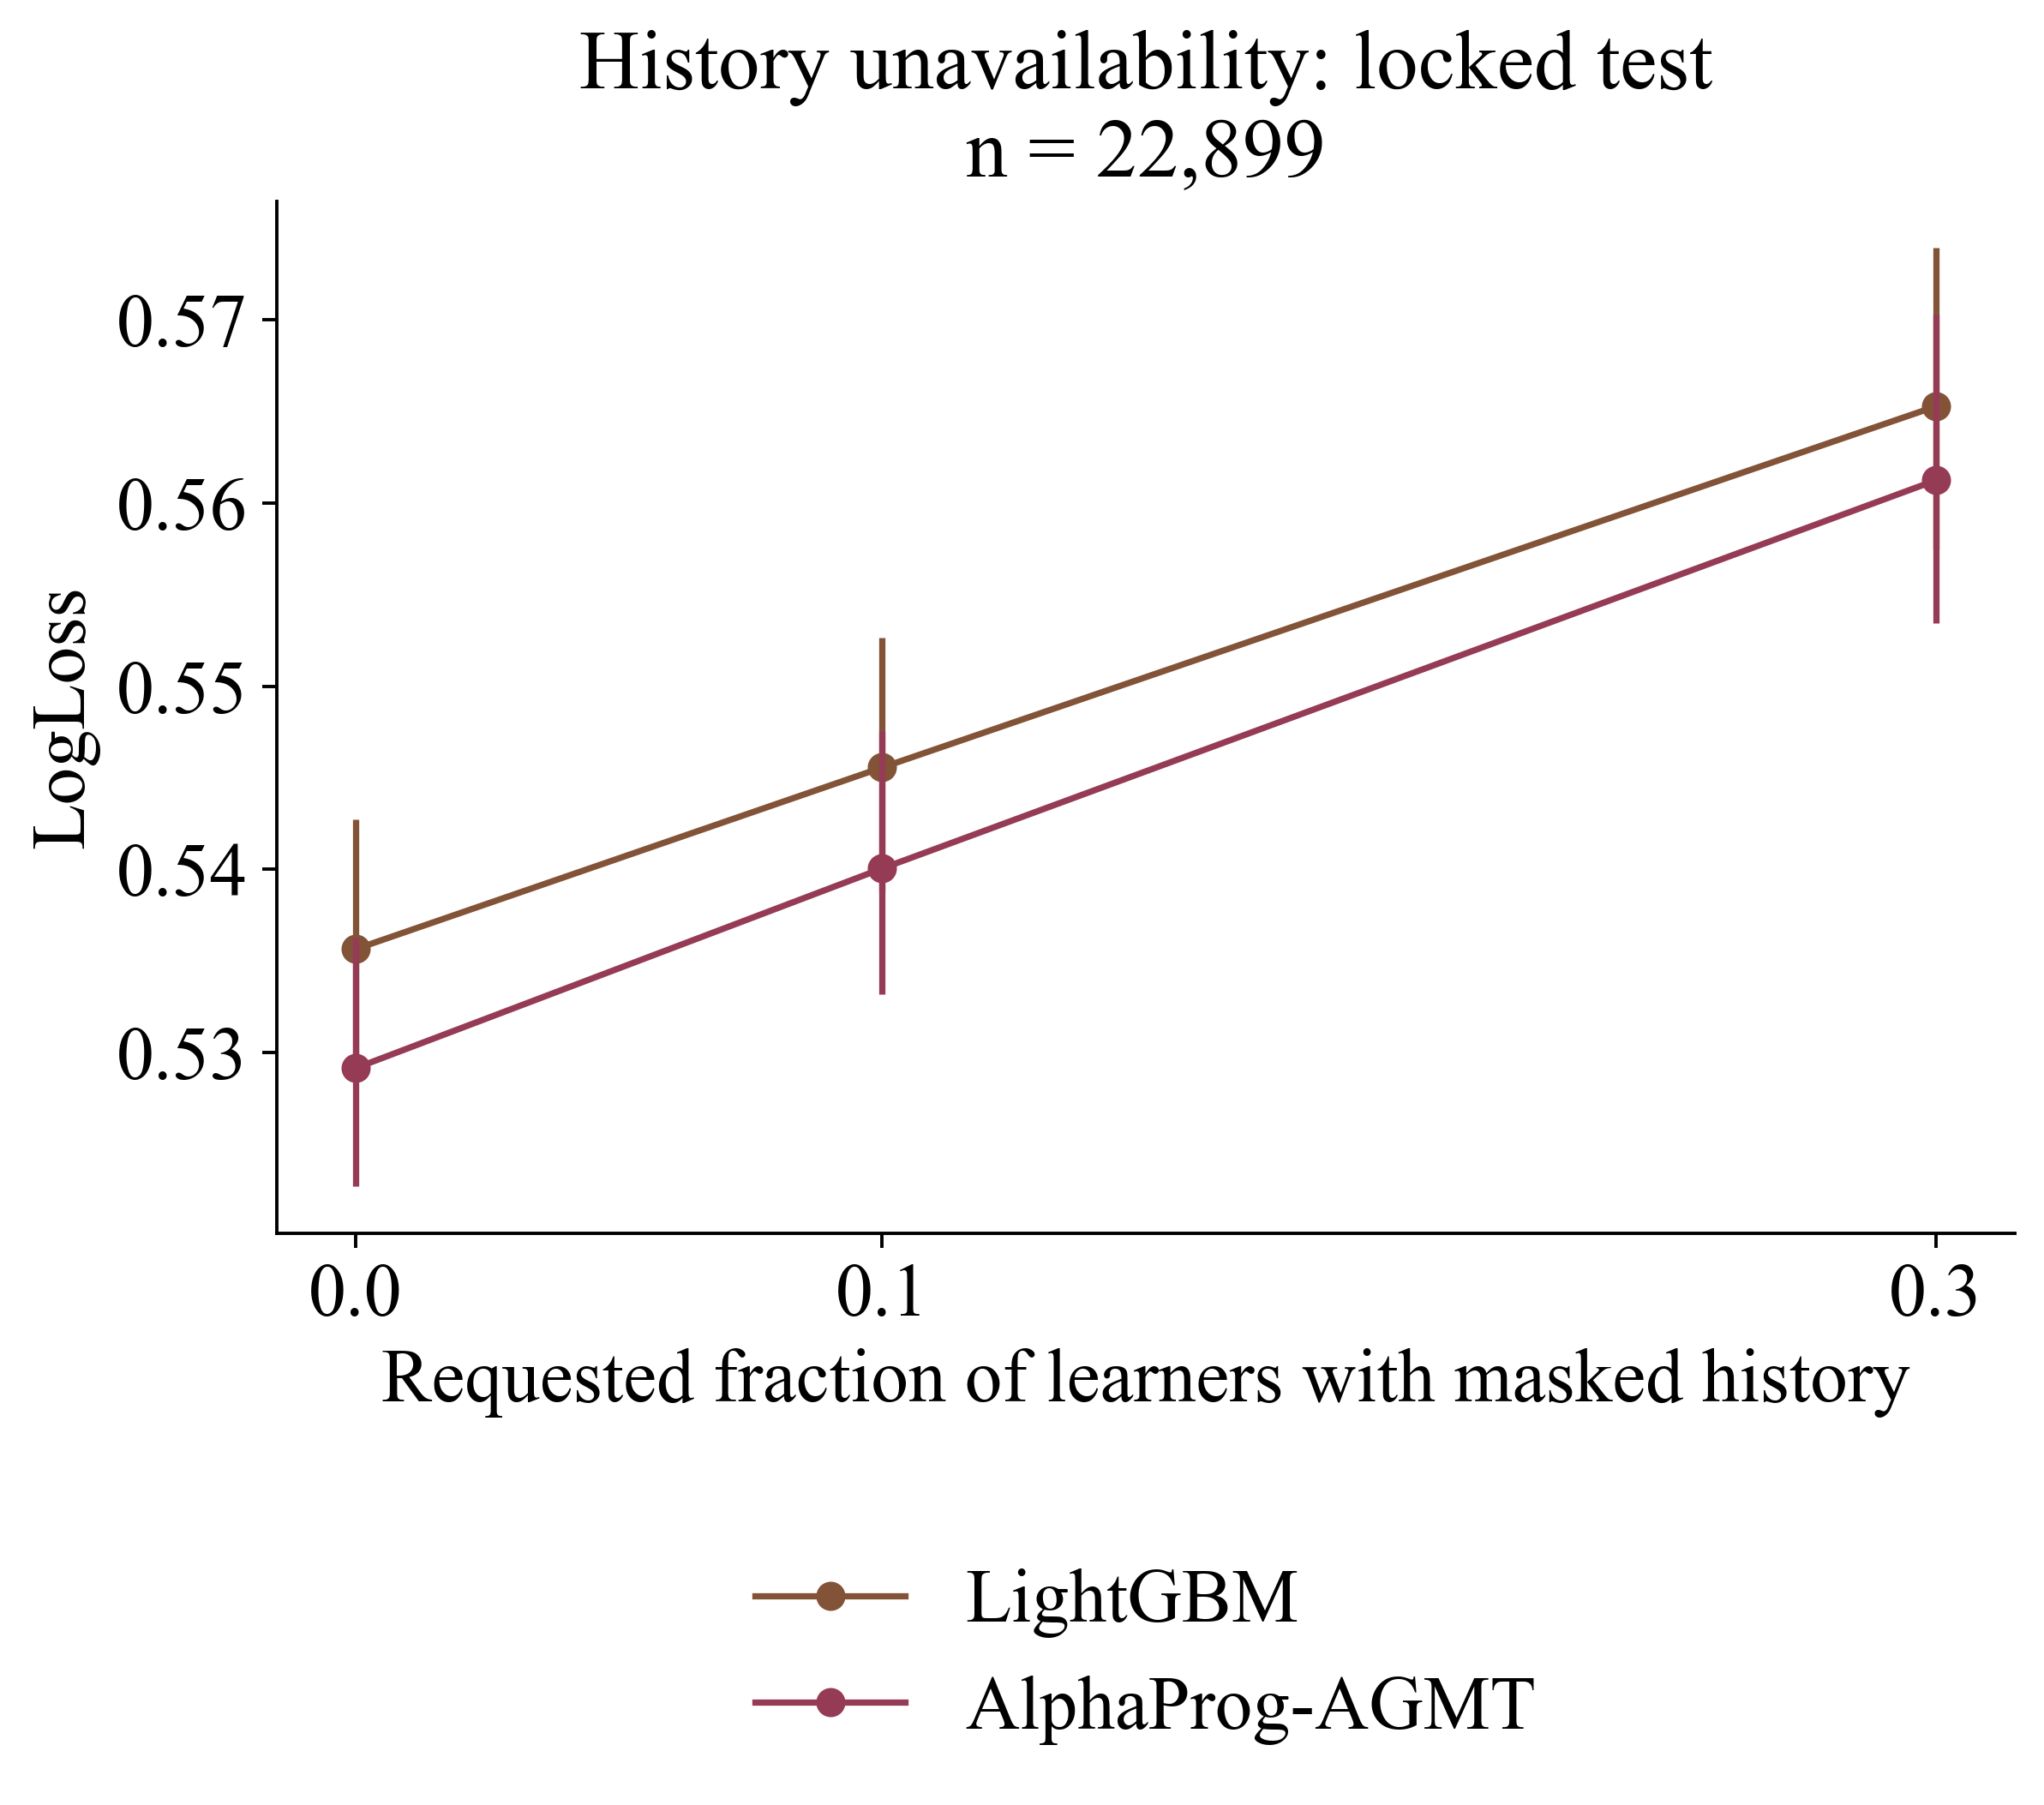

In [23]:
robustness_rows = []
for fraction in frozen["robust_history_mask_fractions"]:
    if fraction == 0:
        predictions = {
            name: probability_matrix[name].to_numpy()
            for name in [BASE_NAME, "AlphaProg-AGMT"]
        }
        masked = np.zeros(len(test_data), dtype=bool)
    else:
        perturbed, perturbed_history, perturbed_sequence, masked = (
            mask_history(test_data, history_test, sequence_test, fraction)
        )
        predictions = robustness_forecast(
            perturbed, perturbed_history, perturbed_sequence
        )
    for name, probability in predictions.items():
        losses = binary_loss(test_data.y.to_numpy(), probability)
        estimate, lower, upper = learner_mean_interval(
            losses, test_data.student.to_numpy(), 500
        )
        robustness_rows.append(
            {
                "Model": name,
                "Split": "Locked test",
                "n": len(test_data),
                "Mask_fraction": fraction,
                "Masked_queries": int(masked.sum()),
                "LogLoss": estimate,
                "CI_low": lower,
                "CI_high": upper,
            }
        )
robustness_results = pd.DataFrame(robustness_rows)
robustness_results.to_csv(
    ROOT / "artifacts/06_history_robustness.csv", index=False
)
fig, ax = plt.subplots(figsize=(6.7, 5.9), layout="constrained")
for (name, group), color in zip(
    robustness_results.groupby("Model", sort=False), ["#825337", "#963B55"]
):
    ax.plot(group.Mask_fraction, group.LogLoss, "o-", color=color, label=name)
    ax.vlines(
        group.Mask_fraction,
        group.CI_low,
        group.CI_high,
        color=color,
        linewidth=1.5,
    )
ax.set(
    xlabel="Requested fraction of learners with masked history",
    ylabel="LogLoss",
    title=f"History unavailability: locked test\nn = {len(test_data):,}",
)
ax.set_xticks(frozen["robust_history_mask_fractions"])
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.26), frameon=False)
save_figure(fig, "06_history_robustness")
plt.show()


## Закрытая проверка абляций

В этой таблице все варианты, включая полную модель, относятся к одному заранее заданному seed 17. Это сопоставление компонентов, поэтому его не смешивают с основным сравнением ансамблей трёх seeds. Конфигурации и веса gate переносятся без изменения из validation-этапа.

In [24]:
ablation_predictions = {
    "AlphaProg-AGMT": joint_by_seed[("AlphaProg-AGMT", SEEDS[0])]
}
base_joint = np.c_[
    forecast_by_seed[(BASE_NAME, SEEDS[0])], hazard_by_seed[SEEDS[0]]
]
for variant in frozen["ablation_variants"]:
    graph_joint = predict_graph(variant, SEEDS[0], test_data, history_test)
    if variant == "NoAuxLoss":
        graph_joint[:, 1] = base_joint[:, 1]
    ablation_predictions[variant], _, _ = apply_fitted_gate(
        test_data,
        base_joint,
        graph_joint,
        experiments["gates"][(variant, SEEDS[0])],
    )
ablation_predictions["ConstantFusion"], _, _ = apply_fitted_gate(
    test_data,
    base_joint,
    graph_by_seed[SEEDS[0]],
    experiments["gates"][("ConstantFusion", SEEDS[0])],
)
if frozen["ablation_best_single"] == "base":
    ablation_predictions["BestSingle: " + BASE_NAME] = base_joint
else:
    assert frozen["ablation_best_single"] == "graph"
    ablation_predictions["BestSingle: GraphTrajectory"] = graph_by_seed[
        SEEDS[0]
    ]
ablation_test_rows = []
for name, forecast in ablation_predictions.items():
    ablation_test_rows.append(
        {
            "Model": name,
            "Split": "Locked test",
            "n": len(test_data),
            "Seed": SEEDS[0],
            "LogLoss": log_loss(test_data.y, forecast[:, 0]),
            "Brier": brier_score_loss(test_data.y, forecast[:, 0]),
            "Effort_NLL": censored_effort_nll(
                test_data.y.to_numpy(),
                test_data.effort_observed.to_numpy(),
                test_data.effort_runs.to_numpy(),
                forecast[:, 0],
                forecast[:, 1],
            ),
        }
    )
ablation_test_results = pd.DataFrame(ablation_test_rows)
joblib.dump(
    ablation_predictions,
    ROOT / "artifacts/runtime/06_test_ablation_predictions.joblib",
)
table(
    ablation_test_results,
    "Абляции на закрытом тесте: все функции ошибок ↓",
    "06_test_ablations",
)


Абляции на закрытом тесте: все функции ошибок ↓

,Model,Split,n,Seed,LogLoss,Brier,Effort_NLL
0,AlphaProg-AGMT,Locked test,22899,17,0.53014,0.17856,1.56878
1,NoGraphEncoder,Locked test,22899,17,0.53109,0.17889,1.57137
2,NoOrder,Locked test,22899,17,0.53281,0.17958,1.57290
3,NoAuxLoss,Locked test,22899,17,0.53016,0.17855,1.57252
4,NoRegularization,Locked test,22899,17,0.52901,0.17815,1.56934
5,NoEdges,Locked test,22899,17,0.53128,0.17894,1.57064
6,ConstantFusion,Locked test,22899,17,0.53055,0.17868,1.56991
7,BestSingle: GraphTrajectory,Locked test,22899,17,0.53063,0.17877,1.57842


## Внутренняя интерпретируемость gate

Для линейного logit gate вклад входа точно равен произведению стандартизованного значения на соответствующий коэффициент. Полотно показывает средний модуль этих вкладов на тесте для seed 17. Оно описывает механизм выбора эксперта; это не важность признаков всей системы и не причинный эффект на успех.

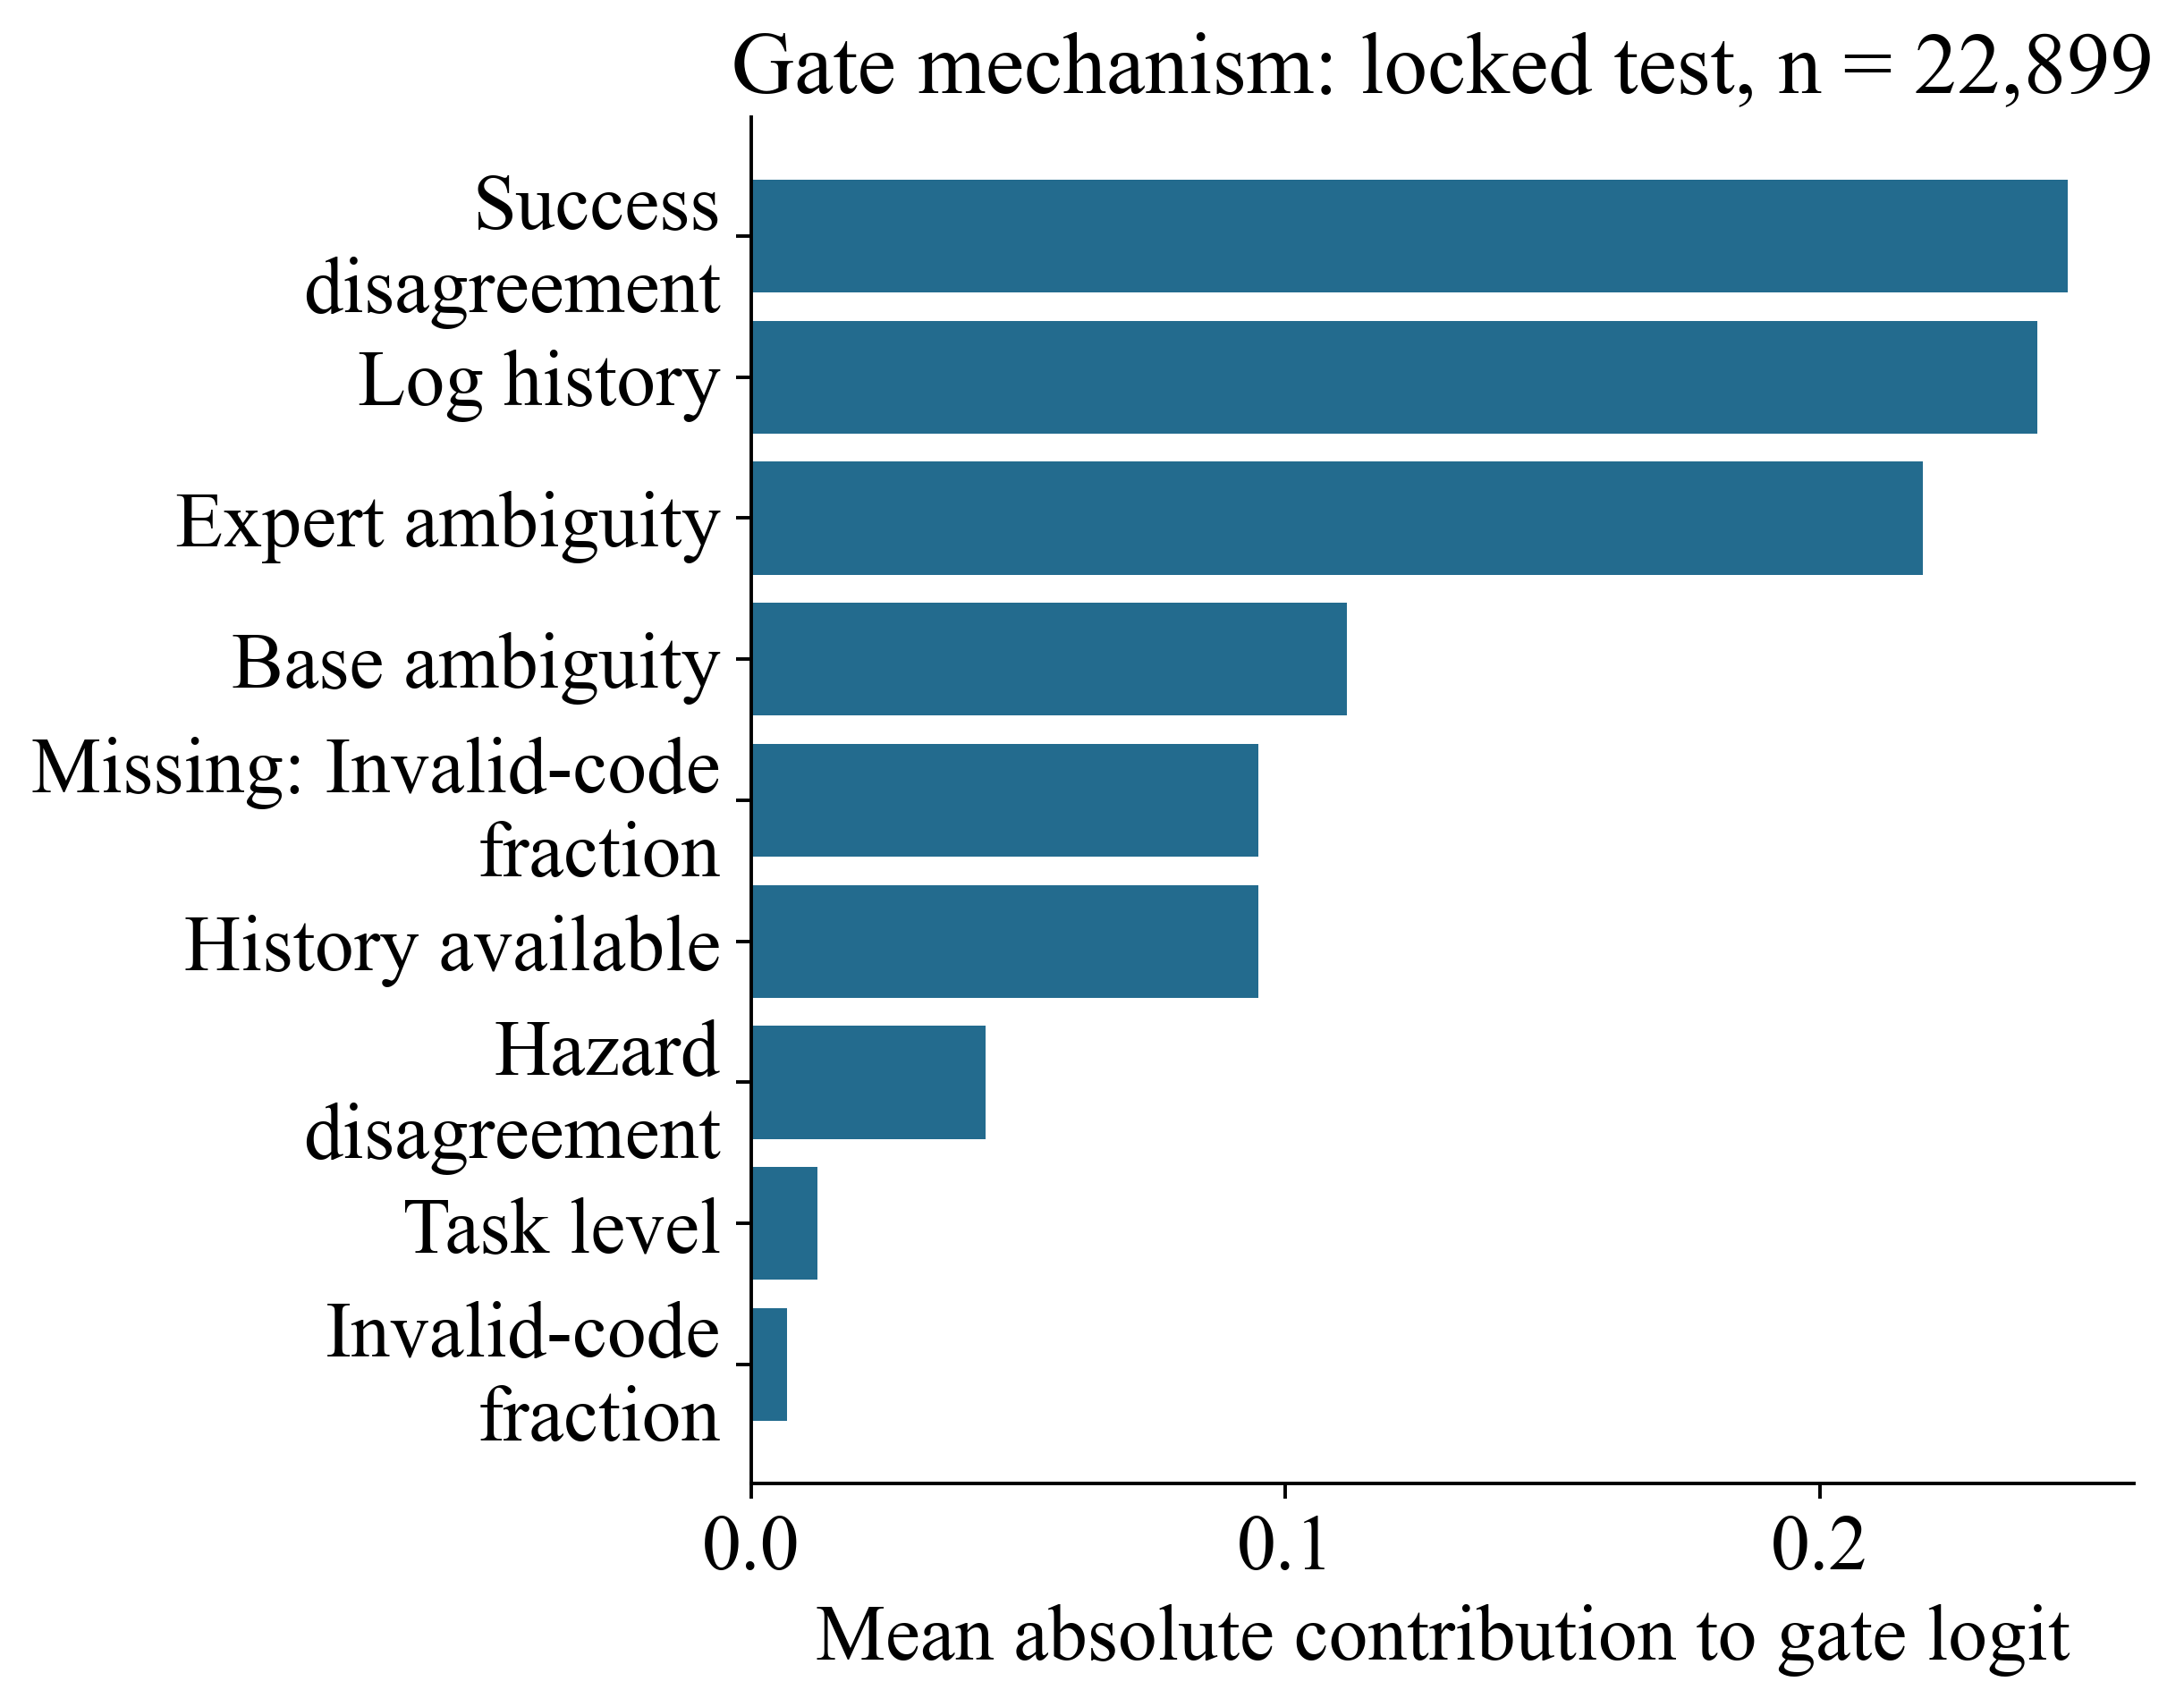

In [25]:
fitted_gate = experiments["gates"][("AlphaProg-AGMT", SEEDS[0])]
context = gate_contexts[SEEDS[0]]["context"]
transformed_context = fitted_gate["preprocessing"].transform(context)
context_names = fitted_gate["preprocessing"].get_feature_names_out(
    context.columns
)
contributions = transformed_context * fitted_gate["coefficients"][1:]
contribution_table = pd.DataFrame(
    {
        "Context": context_names,
        "Mean absolute contribution": np.abs(contributions).mean(axis=0),
    }
)
contribution_table = contribution_table.sort_values(
    "Mean absolute contribution", kind="stable"
)
contribution_table.to_csv(
    ROOT / "artifacts/06_gate_contributions.csv", index=False
)
labels = [
    name.replace("missingindicator_", "Missing: ")
    .replace("Invalid-code fraction", "Invalid-code\nfraction")
    .replace("Success disagreement", "Success\ndisagreement")
    .replace("Hazard disagreement", "Hazard\ndisagreement")
    for name in contribution_table.Context
]
fig, ax = plt.subplots(
    figsize=(6.8, max(4.8, 0.46 * len(labels) + 1.2)), layout="constrained"
)
ax.barh(
    np.arange(len(labels)),
    contribution_table["Mean absolute contribution"],
    color="#236B8E",
)
ax.set_yticks(np.arange(len(labels)), labels)
ax.set(
    xlabel="Mean absolute contribution to gate logit",
    title=f"Gate mechanism: locked test, n = {len(test_data):,}",
)
ax.spines[["top", "right"]].set_visible(False)
save_figure(fig, "06_gate_contributions")
plt.show()


## Ошибки и уверенность прогноза

ECDF индивидуальной логарифмической ошибки показывает хвосты, скрытые средним значением. Она включает все запросы без удаления редких больших ошибок. Второе полотно рассматривает ошибку при различной уверенности классификации; уверенность не является вероятностью истинности объяснения или знания навыка.

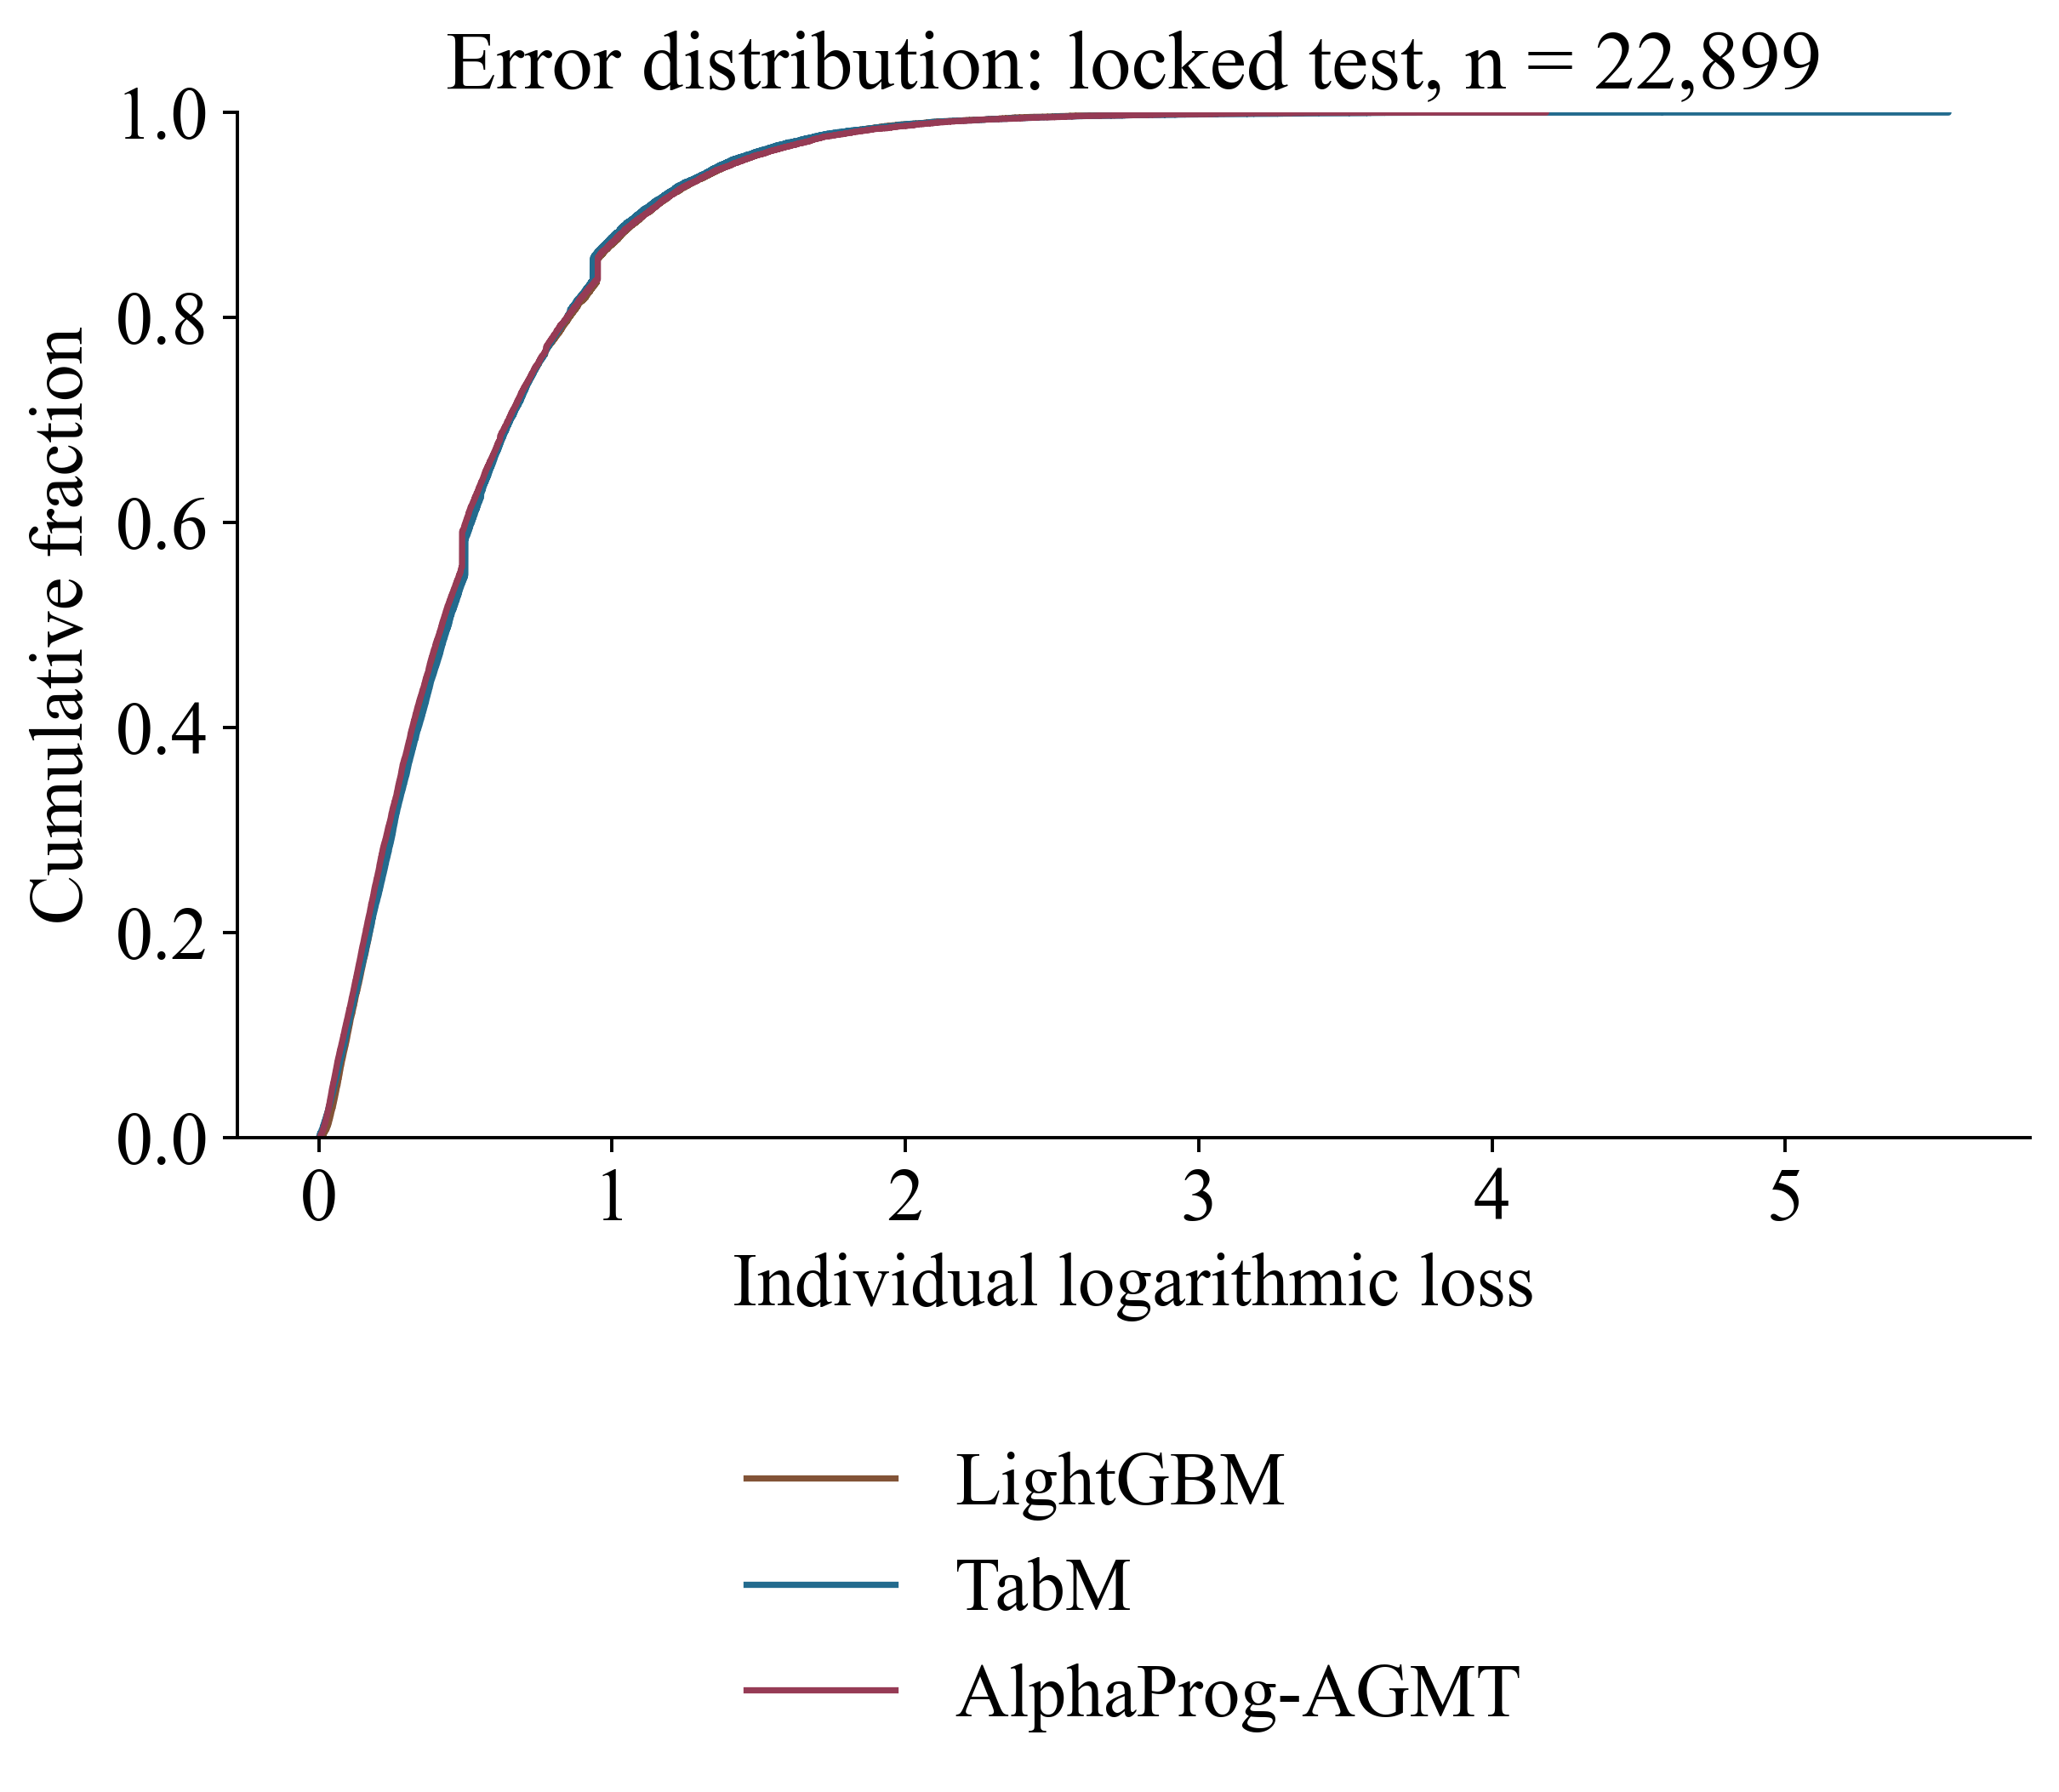

In [26]:
error_sources = []
fig, ax = plt.subplots(figsize=(6.8, 5.9), layout="constrained")
for name, color in zip(diagnostic_models, ["#825337", "#236B8E", "#963B55"]):
    losses = binary_loss(
        test_data.y.to_numpy(), probability_matrix[name].to_numpy()
    )
    values, counts = np.unique(losses, return_counts=True)
    cumulative = counts.cumsum() / counts.sum()
    ax.step(values, cumulative, where="post", label=name, color=color)
    error_sources.append(
        pd.DataFrame(
            {"Model": name, "Loss": values, "Cumulative fraction": cumulative}
        )
    )
ax.set(
    xlabel="Individual logarithmic loss",
    ylabel="Cumulative fraction",
    ylim=(0, 1),
    title=f"Error distribution: locked test, n = {len(test_data):,}",
)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.24), frameon=False)
pd.concat(error_sources).to_csv(
    ROOT / "artifacts/06_error_ecdf.csv", index=False
)
save_figure(fig, "06_error_ecdf")
plt.show()


## Связь уверенности с ошибкой

Уменьшается ли доля неправильных решений при росте предсказанной уверенности? Используется фиксированный порог класса 0,5 и заранее заданные интервалы уверенности шириной 0,1. Интервалы неопределённости строятся по целым учащимся; порог по тесту не подбирается.

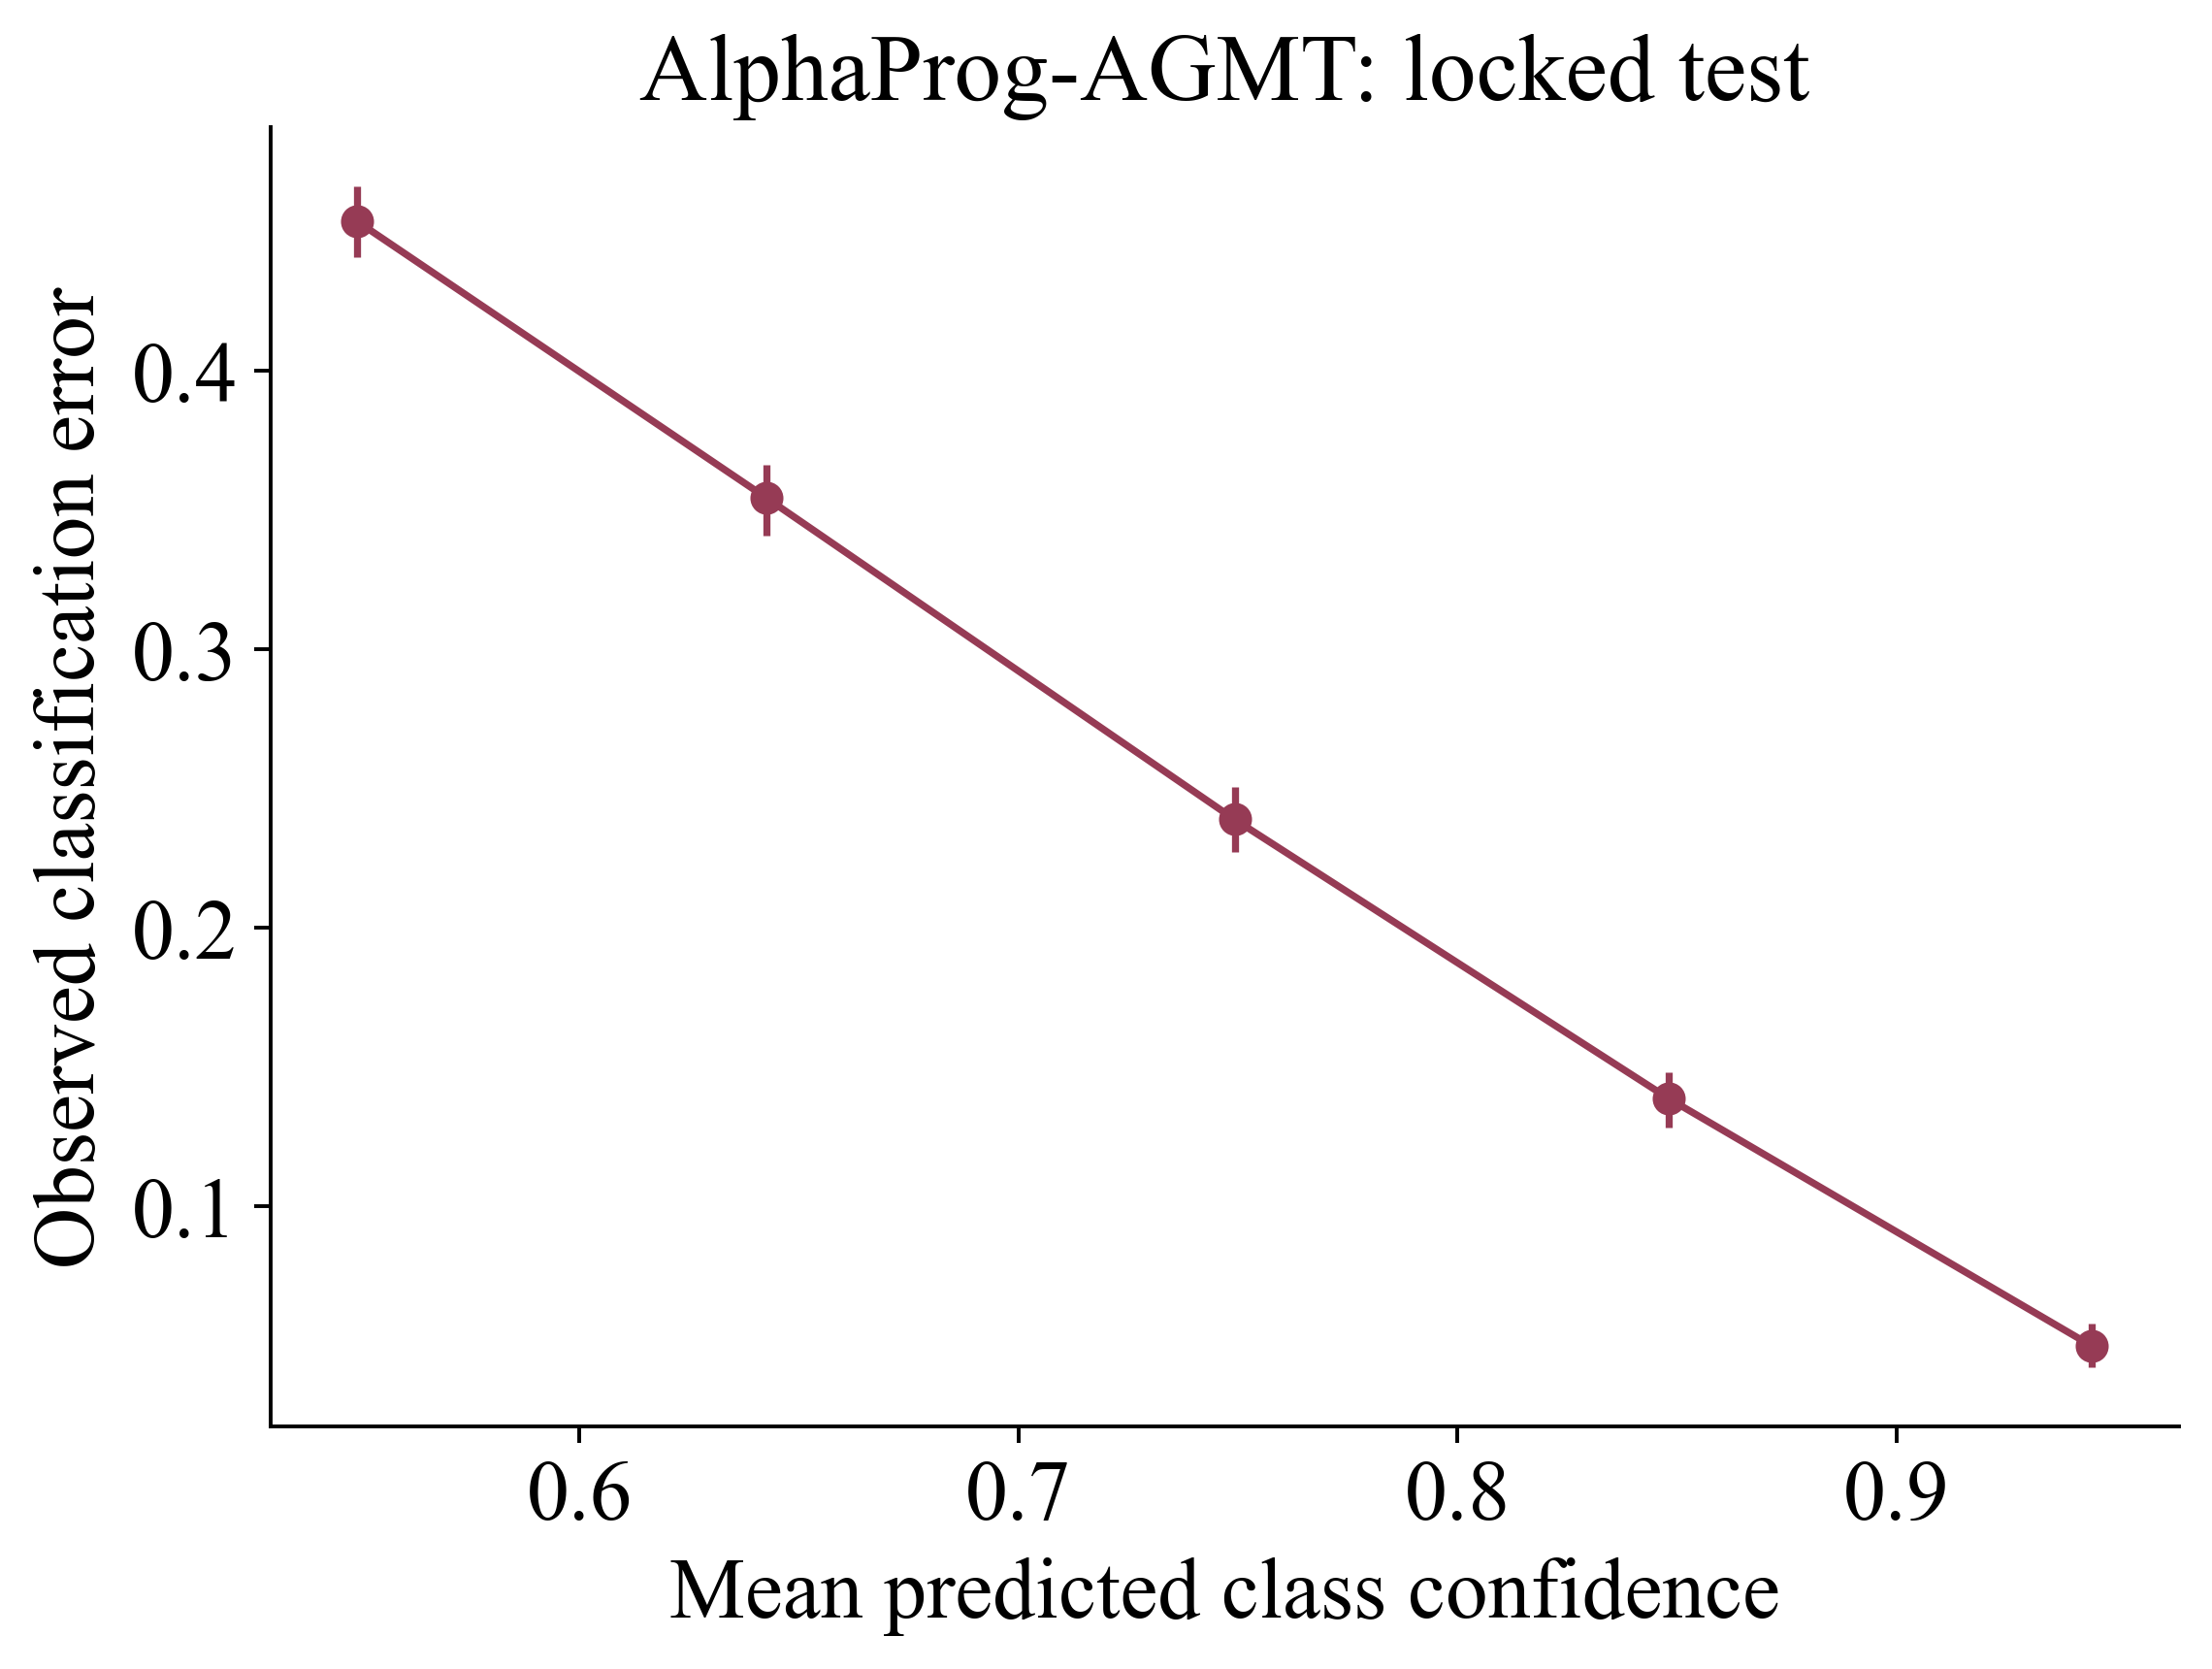

In [27]:
candidate_probability = probability_matrix["AlphaProg-AGMT"].to_numpy()
confidence = np.maximum(candidate_probability, 1 - candidate_probability)
incorrect = (
    (candidate_probability >= 0.5).astype(int) != test_data.y.to_numpy()
).astype(float)
confidence_groups = pd.cut(
    confidence, [0.5, 0.6, 0.7, 0.8, 0.9, 1], include_lowest=True
)
confidence_rows = []
for group in confidence_groups.categories:
    selected = confidence_groups == group
    if not selected.any():
        continue
    estimate, lower, upper = learner_mean_interval(
        incorrect[selected], test_data.loc[selected, "student"].to_numpy(), 500
    )
    confidence_rows.append(
        {
            "Confidence": float(confidence[selected].mean()),
            "Error rate": estimate,
            "CI_low": lower,
            "CI_high": upper,
            "n": int(selected.sum()),
        }
    )
confidence_table = pd.DataFrame(confidence_rows)
confidence_table.to_csv(
    ROOT / "artifacts/06_confidence_errors.csv", index=False
)
fig, ax = plt.subplots(figsize=(6.4, 4.8), layout="constrained")
ax.plot(
    confidence_table.Confidence,
    confidence_table["Error rate"],
    "o-",
    color="#963B55",
)
ax.vlines(
    confidence_table.Confidence,
    confidence_table.CI_low,
    confidence_table.CI_high,
    color="#963B55",
)
ax.set(
    xlabel="Mean predicted class confidence",
    ylabel="Observed classification error",
    title="AlphaProg-AGMT: locked test",
)
ax.spines[["top", "right"]].set_visible(False)
save_figure(fig, "06_confidence_errors")
plt.show()


## Примеры наименьших и наибольших ошибок

Два наименьших и два наибольших индивидуальных LogLoss выбираются детерминированно для seed 17. Таблицы раскрывают прогноз и точное разложение смеси. Это иллюстрации поведения, а не отбор наблюдений для оценки метрик.

In [28]:
case_probability = forecast_by_seed[("AlphaProg-AGMT", SEEDS[0])]
case_loss = binary_loss(test_data.y.to_numpy(), case_probability)
ordered = np.argsort(case_loss, kind="stable")
case_indices = np.r_[ordered[:2], ordered[-2:][::-1]]
case_names = [
    "Lowest loss 1",
    "Lowest loss 2",
    "Highest loss 1",
    "Highest loss 2",
]
case_rows = []
for label, index in zip(case_names, case_indices):
    explanation = gate_contexts[SEEDS[0]]
    case_rows.append(
        {
            "Model": "AlphaProg-AGMT",
            "Split": "Locked test",
            "n": 1,
            "Case": label,
            "y": int(test_data.y.iloc[index]),
            "Probability": float(case_probability[index]),
            "Base_probability": float(explanation["base"][index, 0]),
            "Graph_probability": float(explanation["graph"][index, 0]),
            "Expert_weight": float(explanation["weight"][index]),
        }
    )
case_results = pd.DataFrame(case_rows)
assert np.allclose(
    case_results.Probability,
    (1 - case_results.Expert_weight) * case_results.Base_probability
    + case_results.Expert_weight * case_results.Graph_probability,
)
case_results.to_csv(ROOT / "artifacts/06_all_case_results.csv", index=False)
table(
    case_results[["Model", "Split", "n", "Case", "y", "Probability"]],
    "Первый исход и прогноз: seed 17",
    "06_case_outcomes",
)


Первый исход и прогноз: seed 17

,Model,Split,n,Case,y,Probability
0,AlphaProg-AGMT,Locked test,1,Lowest loss 1,0,0.00193
1,AlphaProg-AGMT,Locked test,1,Lowest loss 2,0,0.00210
2,AlphaProg-AGMT,Locked test,1,Highest loss 1,1,0.01698
3,AlphaProg-AGMT,Locked test,1,Highest loss 2,1,0.02859


In [30]:
table(
    case_results[
        [
            "Model",
            "Split",
            "n",
            "Case",
            "Base_probability",
            "Graph_probability",
            "Expert_weight",
        ]
    ],
    "Точное разложение адаптивной смеси: seed 17",
    "06_case_contributions",
)


Точное разложение адаптивной смеси: seed 17

,Model,Split,n,Case,Base_probability,Graph_probability,Expert_weight
0,AlphaProg-AGMT,Locked test,1,Lowest loss 1,0.00467,0.00009,0.59770
1,AlphaProg-AGMT,Locked test,1,Lowest loss 2,0.00452,0.00057,0.61094
2,AlphaProg-AGMT,Locked test,1,Highest loss 1,0.03261,0.01018,0.69663
3,AlphaProg-AGMT,Locked test,1,Highest loss 2,0.04804,0.01637,0.61412


## Ошибки во времени

Календарные кварталы используются как диагностические подгруппы внутри теста новых учащихся. Train и test охватывают общий период, поэтому этот анализ не является проверкой будущего временного переноса. Изменения ошибки могут отражать другой состав заданий и учеников.

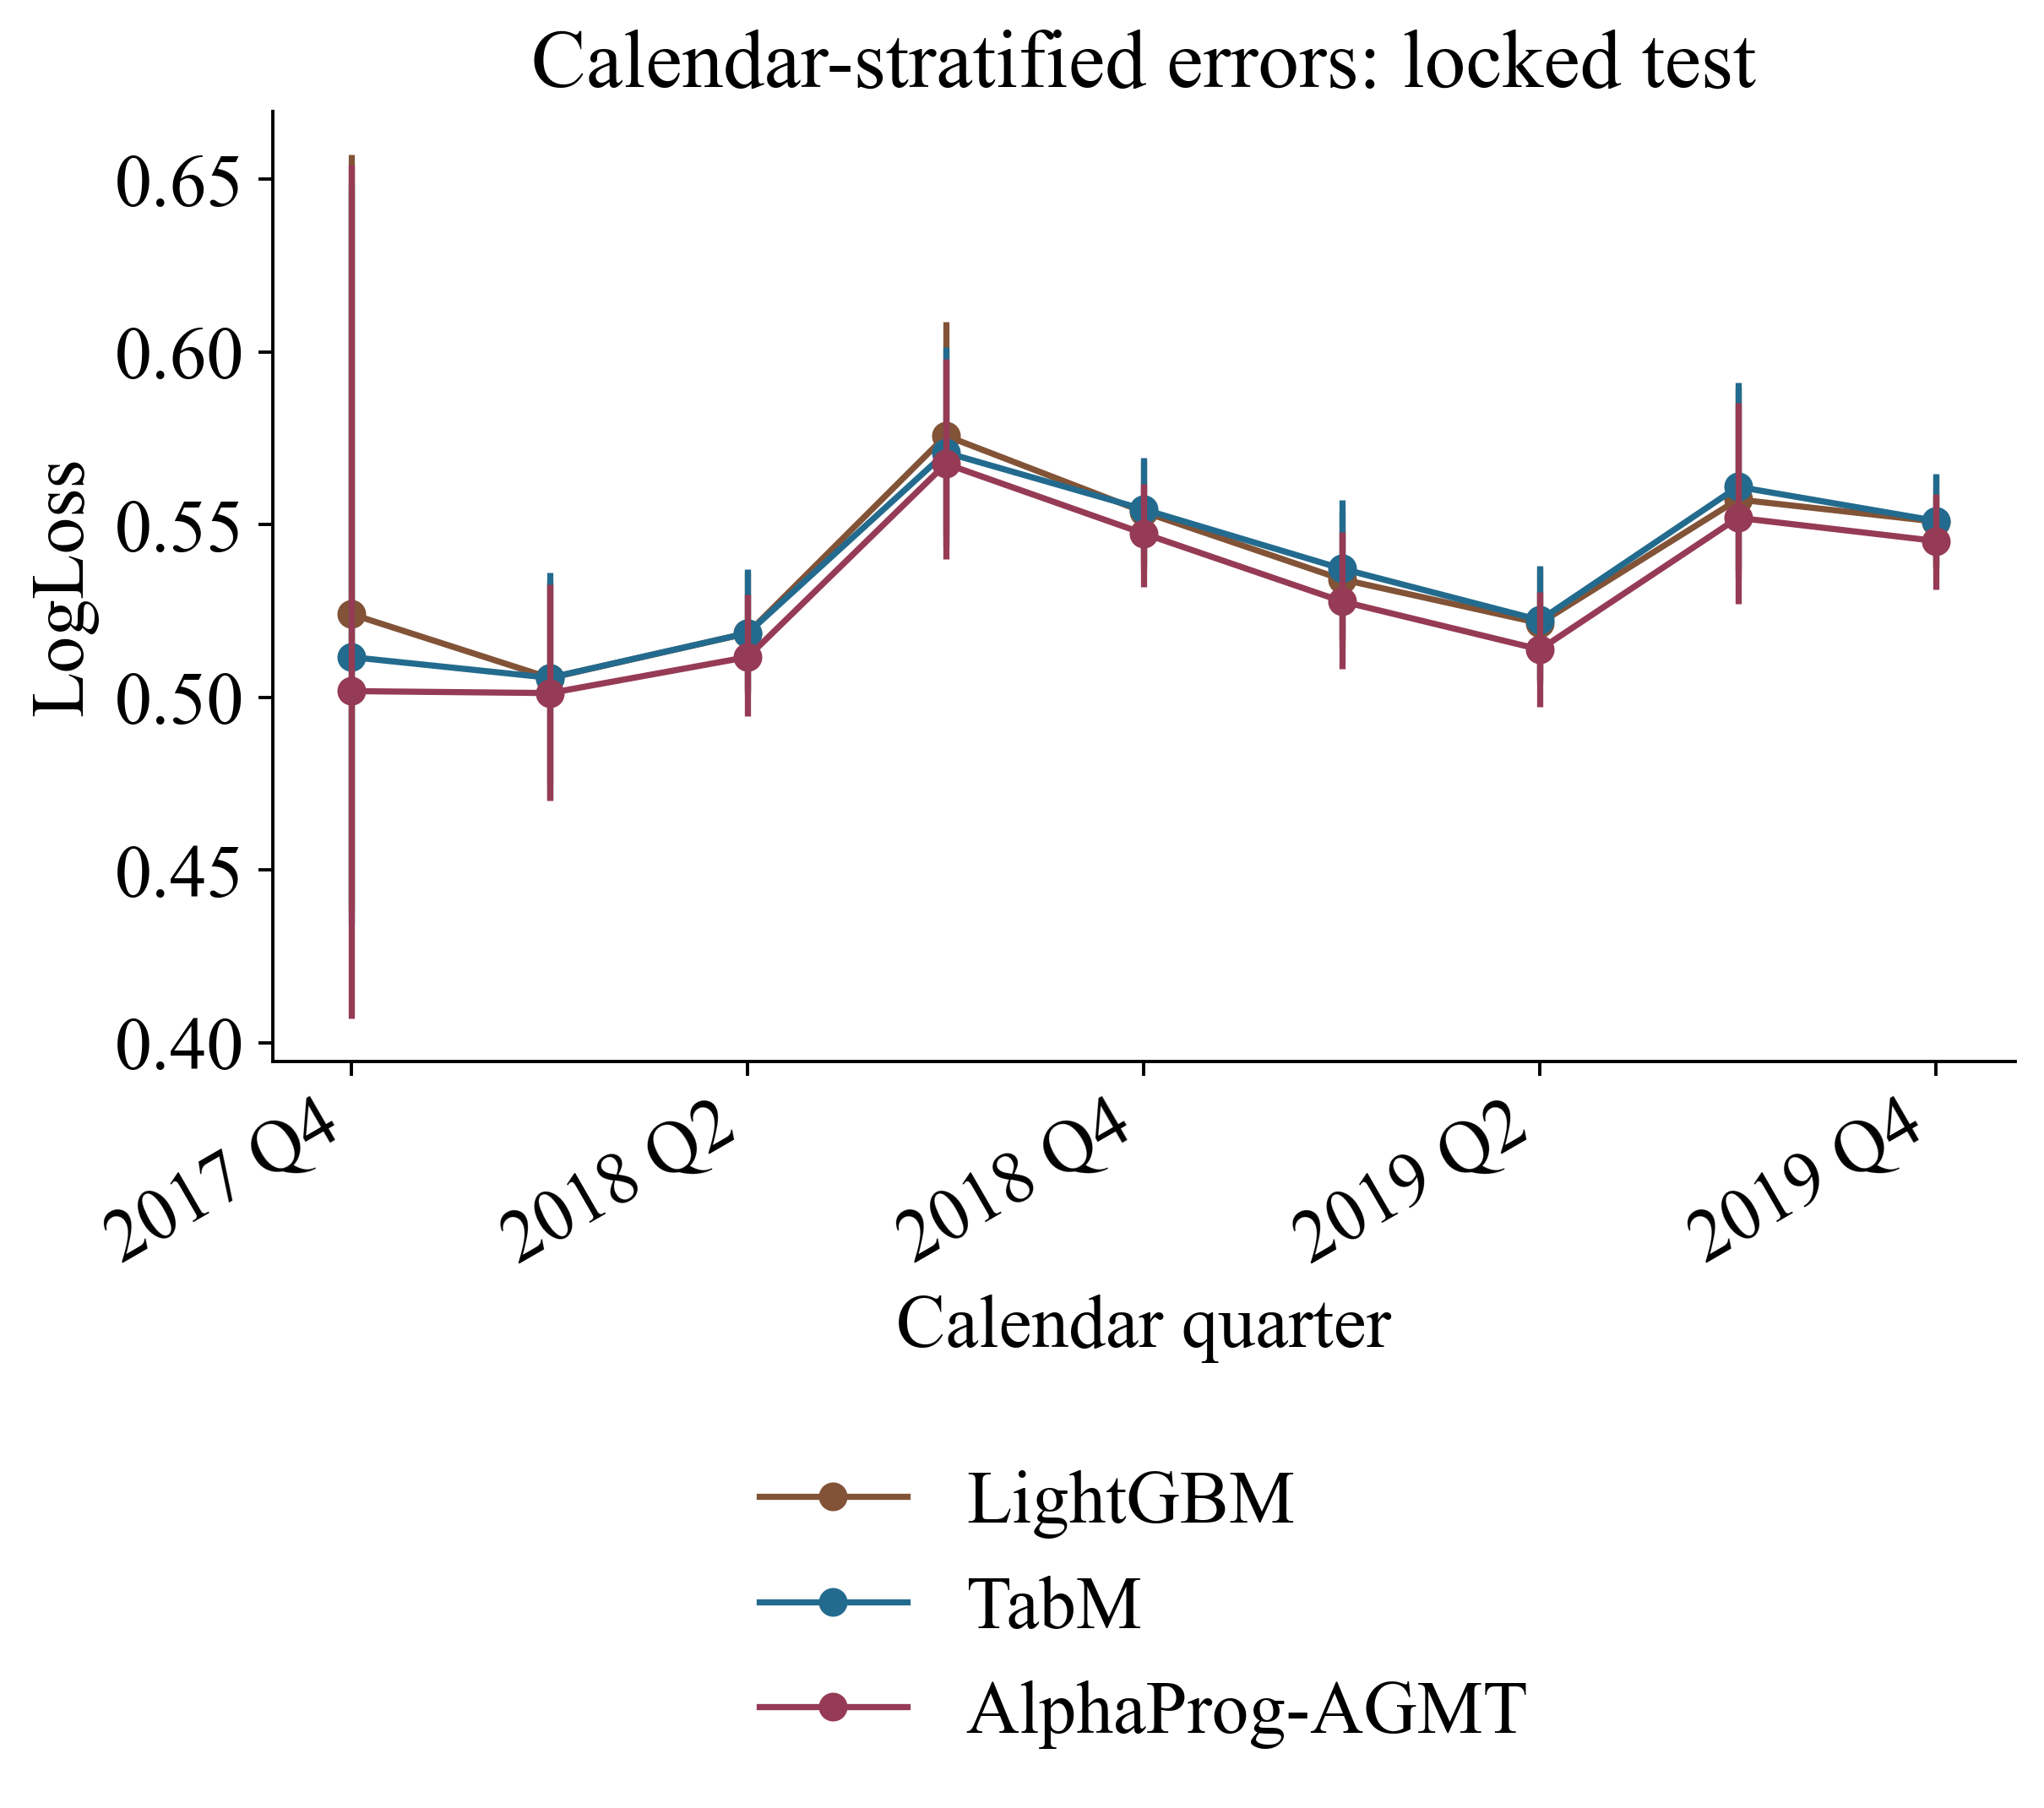

In [29]:
quarters = (
    test_data.start.dt.strftime("%Y")
    + " Q"
    + test_data.start.dt.quarter.astype(str)
)
quarter_rows = []
quarter_order = sorted(quarters.unique())
for quarter in quarter_order:
    retained = quarters.eq(quarter).to_numpy()
    for name in diagnostic_models:
        loss = binary_loss(
            test_data.loc[retained, "y"].to_numpy(),
            probability_matrix.loc[retained, name].to_numpy(),
        )
        estimate, lower, upper = learner_mean_interval(
            loss, test_data.loc[retained, "student"].to_numpy(), 300
        )
        quarter_rows.append(
            {
                "Model": name,
                "Split": "Locked test",
                "Quarter": quarter,
                "n": int(retained.sum()),
                "LogLoss": estimate,
                "CI_low": lower,
                "CI_high": upper,
            }
        )
quarter_results = pd.DataFrame(quarter_rows)
quarter_results.to_csv(ROOT / "artifacts/06_temporal_errors.csv", index=False)
fig, ax = plt.subplots(figsize=(6.8, 6.0), layout="constrained")
positions = np.arange(len(quarter_order))
for name, color in zip(diagnostic_models, ["#825337", "#236B8E", "#963B55"]):
    group = (
        quarter_results[quarter_results.Model.eq(name)]
        .set_index("Quarter")
        .loc[quarter_order]
    )
    ax.plot(positions, group.LogLoss, "o-", label=name, color=color)
    ax.vlines(positions, group.CI_low, group.CI_high, color=color)
ax.set_xticks(positions[::2], quarter_order[::2], rotation=30, ha="right")
ax.set(
    xlabel="Calendar quarter",
    ylabel="LogLoss",
    title="Calendar-stratified errors: locked test",
)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.36), frameon=False)
save_figure(fig, "06_temporal_errors")
plt.show()


## Ошибки по целевому исходу

Поскольку основная цель бинарная, диапазоны цели представлены двумя фактическими классами. Условные ошибки по исходу помогают выявить асимметрию, которую скрывает средний LogLoss.

In [31]:
outcome_rows = []
for outcome in [0, 1]:
    selected = test_data.y.eq(outcome).to_numpy()
    for name in diagnostic_models:
        loss = binary_loss(
            test_data.loc[selected, "y"].to_numpy(),
            probability_matrix.loc[selected, name].to_numpy(),
        )
        outcome_rows.append(
            {
                "Model": name,
                "Split": "Locked test",
                "n": int(selected.sum()),
                "Outcome": outcome,
                "LogLoss": loss.mean(),
            }
        )
outcome_results = pd.DataFrame(outcome_rows)
table(
    outcome_results,
    "Условный LogLoss по фактическому первому исходу ↓",
    "06_outcome_errors",
)


Условный LogLoss по фактическому первому исходу ↓

,Model,Split,n,Outcome,LogLoss
0,LightGBM,Locked test,12987,0,0.46171
1,TabM,Locked test,12987,0,0.45513
2,AlphaProg-AGMT,Locked test,12987,0,0.45538
3,LightGBM,Locked test,9912,1,0.63252
4,TabM,Locked test,9912,1,0.64267
5,AlphaProg-AGMT,Locked test,9912,1,0.62579


## Вычислительная эффективность

Основное сравнение относится к ансамблю трёх seeds, кроме детерминированных ориентиров. Время полного fit суммируется по сохранённым компонентам. Поиск настроек и получение OOF-прогнозов в этот показатель не включены, поэтому он не является полной стоимостью разработки и обучения fusion. Inference включает загрузку весов и подготовку входов внутри вызова; для предлагаемой модели это сумма последовательных компонентных измерений. Общая подготовка последовательностей оценивается отдельно.

Размер файлов включает сохранённые веса, словари и обученные преобразования. Производный кэш входных синтаксических структур не входит в веса и исключён из Stored_MB, как и входные массивы остальных методов; его построение включено во время соответствующего вызова инференса. Число нейросетевых параметров не эквивалентно числу узлов деревьев, а пиковая оперативная память отдельно не измерялась. По этим данным нельзя объявлять превосходство по памяти. Устройство указано явно; CPU- и MPS-времена не позволяют изолировать эффект архитектуры от аппаратного исполнения. Интервалы качества условны на обученных моделях: bootstrap учащихся не повторяет всё обучение.

In [32]:
baseline_efficiency = pd.read_csv(ROOT / "artifacts/03_efficiency.csv")
modern_efficiency = pd.read_csv(ROOT / "artifacts/04_efficiency.csv")
graph_efficiency = pd.read_csv(ROOT / "artifacts/05_graph_efficiency.csv")
fit_seconds = (
    baseline_efficiency.groupby("Model")["Train seconds"].sum().to_dict()
)
fit_seconds.update(modern_efficiency.groupby("Model").Train_s.sum().to_dict())
fit_seconds["GraphTrajectory"] = graph_efficiency[
    graph_efficiency.Model.eq("FullGraph")
].Train_s.sum()
fit_seconds["AlphaProg-AGMT"] = (
    fit_seconds[BASE_NAME]
    + fit_seconds["GraphTrajectory"]
    + sum(
        experiments["hazards"][seed]["full_fit_s"]
        + experiments["gates"][("AlphaProg-AGMT", seed)]["fit_s"]
        for seed in SEEDS
    )
)
file_sets = {}
for name in PRIMARY_MODELS[:10]:
    if name in ["GlobalMean", "ItemMean"]:
        file_sets[name] = [ROOT / f"artifacts/runtime/baselines/{name}.joblib"]
    elif name in MODERN_MODELS:
        file_sets[name] = [
            ROOT / f"artifacts/runtime/modern/{name}_{seed}{suffix}"
            for seed in SEEDS
            for suffix in [".pt", "_preprocessing.joblib"]
        ]
    else:
        file_sets[name] = [
            ROOT / f"artifacts/runtime/baselines/{name}_{seed}.joblib"
            for seed in SEEDS
        ]
file_sets["GraphTrajectory"] = [
    ROOT / f"artifacts/runtime/proposed/FullGraph_{seed}{suffix}"
    for seed in SEEDS
    for suffix in [".pt", "_preprocessing.joblib"]
]
file_sets["AlphaProg-AGMT"] = (
    file_sets[BASE_NAME]
    + file_sets["GraphTrajectory"]
    + [
        ROOT / f"artifacts/runtime/proposed/hazard_{seed}.joblib"
        for seed in SEEDS
    ]
)
# Fusion coefficients and preprocessing are saved separately for storage accounting.
deployment_gate_keys = [
    "coefficients",
    "preprocessing",
    "adaptive",
    "regularization",
    "prior_weight",
    "auxiliary_weight",
]
joblib.dump(
    {
        seed: {
            key: experiments["gates"][("AlphaProg-AGMT", seed)][key]
            for key in deployment_gate_keys
        }
        for seed in SEEDS
    },
    ROOT / "artifacts/runtime/proposed/final_gates.joblib",
)
file_sets["AlphaProg-AGMT"].append(
    ROOT / "artifacts/runtime/proposed/final_gates.joblib"
)
required_model_files = [
    path for model_files in file_sets.values() for path in model_files
]
assert all(
    path.exists() for path in required_model_files
), "A frozen model artifact required for efficiency accounting is missing."
inference_frame = pd.DataFrame(inference_rows)
device_labels = {name: "CPU" for name in PRIMARY_MODELS[:6]}
for name in MODERN_MODELS:
    measured_devices = modern_efficiency.loc[
        modern_efficiency.Model.eq(name), "Device"
    ].unique()
    assert len(measured_devices) == 1
    device_labels[name] = str(measured_devices[0]).upper()
graph_devices = graph_efficiency.loc[
    graph_efficiency.Model.eq("FullGraph"), "Device"
].unique()
assert len(graph_devices) == 1
device_labels["GraphTrajectory"] = str(graph_devices[0]).upper()
device_labels["AlphaProg-AGMT"] = " + ".join(
    sorted({device_labels[BASE_NAME], device_labels["GraphTrajectory"], "CPU"})
)
efficiency_rows = []
for name in PRIMARY_MODELS:
    efficiency_rows.append(
        {
            "Model": name,
            "Split": "Locked test",
            "n": len(test_data),
            "Device": device_labels[name],
            "Full_fit_s": fit_seconds.get(name, np.nan),
            "Inference_s": inference_frame[
                inference_frame.Model.eq(name)
            ].Inference_s.sum(),
            "Stored_MB": (
                sum(path.stat().st_size for path in file_sets[name]) / 1e6
                if file_sets[name]
                else np.nan
            ),
        }
    )
efficiency_results = pd.DataFrame(efficiency_rows)
table(
    efficiency_results,
    "Время в секундах; размер сохранённых моделей в MB",
    "06_efficiency",
)


Время в секундах; размер сохранённых моделей в MB

,Model,Split,n,Device,Full_fit_s,Inference_s,Stored_MB
0,GlobalMean,Locked test,22899,CPU,NaN,0.00056,0.00361
1,ItemMean,Locked test,22899,CPU,NaN,0.00058,0.00361
2,LogisticRegression,Locked test,22899,CPU,32.48178,0.10824,0.03543
3,RandomForest,Locked test,22899,CPU,20.61853,0.46211,46.30235
4,XGBoost,Locked test,22899,CPU,9.59026,0.21722,1.78999
5,LightGBM,Locked test,22899,CPU,10.90925,0.77228,2.38687
6,DKT,Locked test,22899,MPS,69.22413,1.17507,0.60754
7,AKT,Locked test,22899,CPU,2044.29936,13.95089,1.90342
8,UKT,Locked test,22899,MPS,2626.09406,4.40544,1.59997
9,TabM,Locked test,22899,MPS,70.77011,1.17843,0.24860


## Отдельная школьная задача на двух закрытых школах

Модели школьного post-test оцениваются отдельно от RoboMission. Число независимых тестовых школ равно двум; общая ошибка по ученикам не доказывает широкую переносимость на другие школы. Модель по одному pre-test сравнивается с полной анкетной моделью и случайным лесом; все прогнозы ограничены допустимой шкалой 0–24.

In [33]:
school_test = pd.read_pickle(
    ROOT / "dataset/processed/school_locked_test.pkl"
).reset_index(drop=True)
school_contract = json.loads(
    (ROOT / "dataset/protocol/school_features.json").read_text()
)
school_target, pretest = school_contract["target"], school_contract["pretest"]
school_rows = []
school_prediction_rows = []
for name in ["Pretest", "RidgePretest", "RidgeFull", "RandomForest"]:
    if name == "Pretest":
        predicted = school_test[pretest].to_numpy()
    else:
        fitted = joblib.load(
            ROOT / f"artifacts/runtime/baselines/School_{name}.joblib"
        )
        predicted = fitted["model"].predict(school_test[fitted["features"]])
    predicted = np.clip(predicted, 0, 24)
    for group, selected in [
        ("All schools", np.ones(len(school_test), dtype=bool))
    ] + [
        (str(index + 1), school_test.school_group.eq(school).to_numpy())
        for index, school in enumerate(
            sorted(school_test.school_group.unique())
        )
    ]:
        truth = school_test.loc[selected, school_target].to_numpy()
        school_rows.append(
            {
                "Model": name,
                "Split": "Locked school test",
                "Group": group,
                "n": int(selected.sum()),
                "MAE": mean_absolute_error(truth, predicted[selected]),
                "RMSE": np.sqrt(
                    mean_squared_error(truth, predicted[selected])
                ),
                "R2": (
                    r2_score(truth, predicted[selected])
                    if len(truth) >= 2
                    else np.nan
                ),
            }
        )
    school_prediction_rows.append(
        pd.DataFrame(
            {
                "Model": name,
                "source_row": school_test.source_row,
                "school": school_test.school_group,
                "target": school_test[school_target],
                "predicted": predicted,
            }
        )
    )
school_results = pd.DataFrame(school_rows)
pd.concat(school_prediction_rows).to_csv(
    ROOT / "artifacts/runtime/06_school_test_predictions.csv", index=False
)
table(
    school_results,
    "Школьный post-test: MAE и RMSE ↓; R² ↑",
    "06_school_quality",
)


Школьный post-test: MAE и RMSE ↓; R² ↑

,Model,Split,Group,n,MAE,RMSE,R2
0,Pretest,Locked school test,All schools,397,3.45340,4.36294,0.16666
1,Pretest,Locked school test,1,201,3.21393,4.03960,0.29221
2,Pretest,Locked school test,2,196,3.69898,4.67134,0.01932
3,RidgePretest,Locked school test,All schools,397,2.64810,3.35857,0.50617
4,RidgePretest,Locked school test,1,201,2.60355,3.35897,0.51063
5,RidgePretest,Locked school test,2,196,2.69379,3.35816,0.49319
6,RidgeFull,Locked school test,All schools,397,3.02065,3.71307,0.39643
7,RidgeFull,Locked school test,1,201,3.14993,3.88142,0.34656
8,RidgeFull,Locked school test,2,196,2.88807,3.53210,0.43932
9,RandomForest,Locked school test,All schools,397,2.74525,3.45237,0.47820


## Границы интерпретации

Статистическая поддержка оценивается по показанным эффектам, интервалам и скорректированным p-values. Отрицательный или неопределённый результат остаётся результатом исследования; после теста модель не перенастраивается. Bootstrap по учащимся не устраняет возможную зависимость внутри неизвестных классов. Оценка условна на первом посещении с наблюдённым запуском: 2 232 первых посещения без запуска не имеют бинарной метки и не используются как известные неудачи. Validation и test содержат известные задания в общем календарном периоде.

Сценарий отсутствующей истории не заменяет проверку на другой платформе, возрастной группе или педагогическом вмешательстве. Результаты цензурированной трудоёмкости зависят от выбранной геометрической модели и допущений о цензурировании. Внутренние веса объясняют смешивание экспертов, а не истинные компетенции ребёнка. Школьная задача остаётся самостоятельным экспериментом.

Прогноз условен на фактическом выборе задания в архиве. Без рандомизации либо обоснованной причинной off-policy оценки нельзя заключить, что рекомендация другого задания повысит образовательный результат; адаптивные веса предиктора не являются проверенной педагогической политикой.

In [34]:
analysis_bundle = {
    "feature_revision": contract["feature_revision"],
    "frozen_signature": frozen_signature,
    "primary": primary_results,
    "ranking": ranking_results,
    "calibration": calibration_results,
    "statistics": statistical_results,
    "seeds": seed_results,
    "subgroups": subgroup_results,
    "robustness": robustness_results,
    "effort": effort_results,
    "effort_effects": effort_effect_results,
    "ablations": ablation_test_results,
    "efficiency": efficiency_results,
    "school": school_results,
    "cases": case_results,
    "temporal": quarter_results,
    "outcomes": outcome_results,
    "gate_contributions": contribution_table,
    "calibration_bins": pd.concat(calibration_sources),
    "confidence_errors": confidence_table,
    "primary_models": PRIMARY_MODELS,
    "diagnostic_models": diagnostic_models,
}
joblib.dump(
    analysis_bundle, ROOT / "artifacts/runtime/06_analysis_bundle.joblib"
)
revision = json.loads(
    (ROOT / "dataset/protocol/feature_revision.json").read_text()
)
revision.update(
    {
        "status": "analysis_completed",
        "downstream_results_valid": True,
        "locked_test_opened": True,
    }
)
(ROOT / "dataset/protocol/feature_revision.json").write_text(
    json.dumps(revision, indent=2)
);
